# Rush Hour: predicting hourly bike demand

This notebook runs the whole project from top to bottom. Every number comes from our own modules in `src/` and from the
JSON files in `artifacts/`; the cells only call them and show the results.

**Running it on Google Colab (or any fresh machine).** Upload this notebook and the two data files of the course,
`train.csv` and `test.csv`, then choose *Runtime → Run all*. Nothing else is needed: the setup cell below carries our
own project files (the modules in `src/`, `config.yaml`, the stored `artifacts/` and the empty submission template)
as text and unpacks them next to the notebook. It downloads nothing and never overwrites a file that already exists.
If the two data files have not been uploaded yet, the setup cell asks for them. On our own machines, where the project
folder is already there, the setup cell unpacks nothing.

**Runtime.** About two minutes. Phases 1 to 3 are computed live every time the notebook runs (seconds each) and
compared with the artifacts of our own run. Phase 4 takes about 30 minutes to compute and Phase 5 about 3, so those
two cells load the stored artifact when the configuration and the upstream artifact are unchanged, and say so.
To recompute the whole chain from scratch set `RECOMPUTE_ALL = True` in the configuration cell (about 40 minutes).
Numbers recomputed on another machine can differ from the text in the last digits, because the markdown cells quote
the stored run.

**Where the code is.** The cells call our modules in `src/`; the core algorithms are printed where they are used
(`show_source`), and once the setup cell has run every file can be opened from the file browser.

**How to change a setting.** Every knob lives in `config.yaml`. To try a different value, edit the `CFG` dictionary in
the configuration cell (for example `CFG["p1"]["lr_fraction_of_bound"] = 0.9`) and re-run the later cells; the phase
cells pass `CFG` to the phase code. A phase whose configuration changed is recomputed, and so is everything after it,
so a change in Phase 1 or 2 costs the 30 minutes of Phase 4 and overwrites the stored artifacts and the submission
file (`git checkout -- artifacts sample_submission.csv` restores them in our repository; on Colab, restart and run the
setup cell again in a clean session). For a quick demonstration that does not touch the chain, call the functions
directly in a scratch cell (examples are in `docs/WALKTHROUGH.md`).

In [1]:
# SETUP: run this cell first. It unpacks our project files, stored below as text, and makes sure the two data files are
# in place. The long block of letters is a compressed copy of src/, config.yaml and artifacts/, nothing else.
import base64
import hashlib
import io
import os
import shutil
import zipfile

BUNDLE = """
...
"""
DATA_SHA256 = {"train": "d75c65afa675373d63ef0f6e81324910605fd378031c2590e4a40c985005e2c1", "test": "2ba21ce32552fa770d0a560ca1512e6700aaaf3adc559a343b8884c80845ddea"}   # the data files our stored results were computed from

with zipfile.ZipFile(io.BytesIO(base64.b64decode(BUNDLE))) as bundle:
    members = bundle.namelist()
    missing_members = [m for m in members if not os.path.exists(m)]
    for member in missing_members:
        bundle.extract(member, ".")
print(f"project files: {len(members)} in the bundle, {len(missing_members)} unpacked now, "
      f"{len(members) - len(missing_members)} already present")
del BUNDLE

import yaml

DATA_PATHS = {key: yaml.safe_load(open("config.yaml", encoding="utf-8"))["paths"][key] for key in DATA_SHA256}


def find_data_file(target):
    """An uploaded copy of a data file: next to the notebook, or in Colab's upload folder."""
    for folder in (".", "/content"):
        candidate = os.path.join(folder, os.path.basename(target))
        if os.path.isfile(candidate):
            return candidate
    return None


def place_data_files():
    """Copy uploaded data files to the paths config.yaml expects; return the ones still missing."""
    still_missing = []
    for target in DATA_PATHS.values():
        if not os.path.isfile(target):
            found = find_data_file(target)
            if found is None:
                still_missing.append(target)
            else:
                os.makedirs(os.path.dirname(target) or ".", exist_ok=True)
                shutil.copy(found, target)
    return still_missing


needed = place_data_files()
if needed:
    names = [os.path.basename(target) for target in needed]
    try:
        from google.colab import files as colab_files
    except ImportError:
        raise FileNotFoundError(f"put {names} next to this notebook (or in data/) and run this cell again") from None
    print("please choose these files in the upload box:", names)
    for name, content in colab_files.upload().items():
        for target in needed:   # Colab may rename a second upload to 'train (1).csv', so match on the stem
            if name.startswith(os.path.splitext(os.path.basename(target))[0]):
                os.makedirs(os.path.dirname(target) or ".", exist_ok=True)
                with open(target, "wb") as handle:
                    handle.write(content)
    needed = place_data_files()
    if needed:
        raise FileNotFoundError(f"still missing: {needed}; upload them and run this cell again")

DATA_MATCHES = True
for key, target in DATA_PATHS.items():
    with open(target, "rb") as handle:
        digest = hashlib.sha256(handle.read().replace(b"\r\n", b"\n")).hexdigest()
    same = digest == DATA_SHA256[key]
    DATA_MATCHES = DATA_MATCHES and same
    print(f"{target}: {'the file our stored results were computed from' if same else 'DIFFERENT from the file our stored results were computed from'}")
if not DATA_MATCHES:
    print("The stored artifacts do not belong to these data files: set RECOMPUTE_ALL = True in the configuration cell.")

project files: 32 in the bundle, 0 unpacked now, 32 already present
data/train.csv: the file our stored results were computed from
data/test.csv: the file our stored results were computed from


In [2]:
import json
import os
import sys

sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd

from src import plots
from src.common import cached_or_run, config_seed, load_config, load_train, seeded_split, team_seed
import src.phases.p1 as p1mod
import src.phases.p2 as p2mod

CFG = load_config()

RECOMPUTE_ALL = False   # True: recompute every phase from scratch (about 40 minutes) instead of loading artifacts


def largest_difference(a, b):
    """Largest relative difference between the numbers of two artifacts, and how many other entries differ."""
    if isinstance(a, dict) and isinstance(b, dict):
        if a.keys() != b.keys():
            return 0.0, 1
        parts = [largest_difference(a[k], b[k]) for k in a]
    elif isinstance(a, list) and isinstance(b, list):
        if len(a) != len(b):
            return 0.0, 1
        parts = [largest_difference(x, y) for x, y in zip(a, b)]
    elif isinstance(a, float) and isinstance(b, float):
        return abs(a - b) / max(abs(a), abs(b), 1e-12), 0
    else:
        return 0.0, int(a != b)
    return max((p[0] for p in parts), default=0.0), sum(p[1] for p in parts)


def phase(name, run_fn, upstream=None, live=False):
    """Run a phase, or load its stored artifact.

    live=False (the slow Phases 4 and 5): load the stored artifact if it was built from this configuration and
    this upstream artifact, otherwise run the phase.
    live=True (Phases 1 to 3, seconds each): always run the phase here and now, then compare the result with the
    stored artifact. If the stored artifact belongs to this configuration it is put back afterwards, so that the
    later phases, which are tied to it by its hash, stay valid; another machine can differ in the last digits.
    """
    path = os.path.join("artifacts", name + ".json")
    if RECOMPUTE_ALL or not live or not os.path.exists(path) or CFG != load_config():
        return run_fn(CFG) if RECOMPUTE_ALL else cached_or_run(name, run_fn, CFG, upstream=upstream)
    with open(path, "rb") as handle:
        stored_bytes = handle.read()
    stored = json.loads(stored_bytes)
    run_fn(CFG)                                           # the live run; it rewrites artifacts/<name>.json
    with open(path, "rb") as handle:
        fresh = json.loads(handle.read())                 # what the live run wrote
    same_config = stored.get("config_sha256") == fresh.get("config_sha256")
    same_upstream = stored.get("upstream_sha256") == fresh.get("upstream_sha256")
    if not (same_config and same_upstream):
        print(f"{name}: computed live; the stored artifact belonged to another configuration and was replaced")
        return fresh
    worst, other = largest_difference(stored, fresh)
    with open(path, "wb") as handle:
        handle.write(stored_bytes)
    print(f"{name}: computed live just now; largest relative difference to the stored artifact {worst:.1e}, "
          f"{other} other entries differ; stored file kept so that the later phases stay valid")
    return stored
SEED = config_seed(CFG)
assert team_seed(["34521", "40218", "41190"]) == 41698   # the worked example of the brief
print("team ids  :", CFG["team_ids"])
print("seed      :", SEED, "(sha256 of the sorted ids joined by '_', mod 100000)")
print("self-test : 41698 reproduced from the brief's example ids")
print("knobs     : p1 lr fraction =", CFG["p1"]["lr_fraction_of_bound"],
      "| p2 degrees =", CFG["p2"]["degree_candidates"], "| plateau tol =", CFG["p2"]["plateau_tol"])

team ids  : ['16007032', '16009837', '16006283']
seed      : 44615 (sha256 of the sorted ids joined by '_', mod 100000)
self-test : 41698 reproduced from the brief's example ids
knobs     : p1 lr fraction = 0.5 | p2 degrees = [1, 2, 3, 4] | plateau tol = 0.001


In [3]:
import inspect


def show_source(*functions):
    """Print the source code of our own functions, so the algorithm is visible where the notebook uses it."""
    for function in functions:
        print(inspect.getsource(function))

In [4]:
train_all = load_train(CFG)
train_df, val_df = seeded_split(train_all, SEED, CFG["split"]["test_size"])
print("labelled rows :", train_all.shape)
print("train / validation :", train_df.shape, val_df.shape)
print("columns       :", ", ".join(train_all.columns))

labelled rows : (10886, 17)
train / validation : (8708, 17) (2178, 17)
columns       : instant, dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt, ws_lag1, wet3


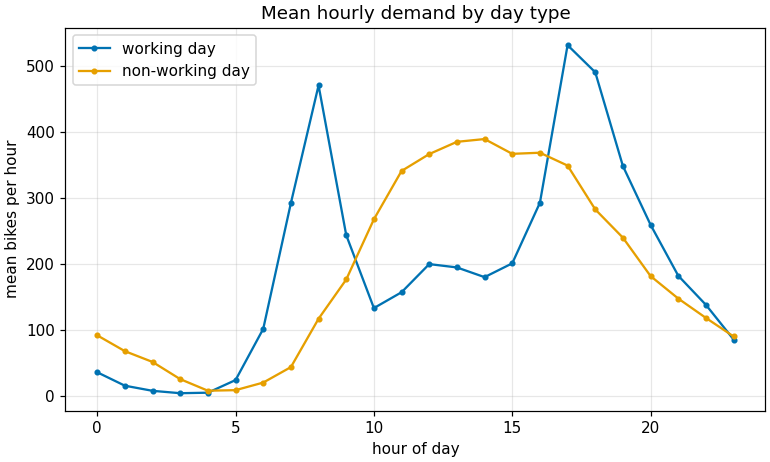

In [5]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plots.plot_demand_profile(train_df))

In [6]:
quirks = pd.Series({
    "rows with hum == 0": int((train_all["hum"] == 0).sum()),
    "share of rows with windspeed == 0": round(float((train_all["windspeed"] == 0).mean()), 4),
    "rows with weathersit == 1": int((train_all["weathersit"] == 1).sum()),
    "rows with weathersit == 2": int((train_all["weathersit"] == 2).sum()),
    "rows with weathersit == 3": int((train_all["weathersit"] == 3).sum()),
    "rows with weathersit == 4": int((train_all["weathersit"] == 4).sum()),
    "correlation of temp and atemp": round(float(np.corrcoef(train_all["temp"], train_all["atemp"])[0, 1]), 4),
    "rows where workingday != (Mon-Fri and not holiday)": int(
        (train_all["workingday"] != (train_all["weekday"].between(1, 5) & (train_all["holiday"] == 0)).astype(int)).sum()),
    "rows where season != calendar quarter of mnth": int((train_all["season"] != (train_all["mnth"] - 1) // 3 + 1).sum()),
}, name="value")
print(quirks.to_string())

rows with hum == 0                                      22.0000
share of rows with windspeed == 0                        0.1206
rows with weathersit == 1                             7192.0000
rows with weathersit == 2                             2834.0000
rows with weathersit == 3                              859.0000
rows with weathersit == 4                                1.0000
correlation of temp and atemp                            0.9849
rows where workingday != (Mon-Fri and not holiday)       0.0000
rows where season != calendar quarter of mnth            0.0000


### What we saw in the data before modelling

**About our expectations.** We looked at the data first, and that look included pilot fits, not only tables. Before writing any Expectation cell we had fitted quick closed-form least-squares models (scripts in `exp/eda0/`) to compare raw and log targets, hour encodings, the working-day × hour block, a first version of the complexity ladder and three candidate label rules for Phase 5. So the Expectation cells are informed predictions, not blind guesses, and some of their numbers are close to the outcomes for that reason. What they could not know, and where they turned out wrong, is said in each Outcome cell. The Expectation cells were committed to git before the corresponding phase code was run and have not been edited since. The same holds, even more strongly, for the second-pass Expectation cells: before writing them we had already fitted the new target on these designs in closed form (`exp/v2/`), so their forecasts are close to the outcomes because we had measured something very similar, not because we foresaw it. What the brief asks of an Expectation, to commit to a prediction and a reason before the phase is run, they do; evidence of foresight they are not.

- **Time structure.** `train.csv` holds days 1-19 of every month of 2011 and 2012; `test.csv` holds the 20th of every month. The hidden test is therefore whole days we have never seen, spread through the same two years. Rows are not independent: hours of one day resemble each other, and every validation row of our seeded split has same-day neighbours in the training portion.
- **Missing hours.** Some hours are absent, mostly between 2 and 5 at night, and `cnt` is never 0. Quiet hours seem to be missing rather than recorded as zero, so our models never see a zero-demand hour.
- **Growth.** Mean demand in 2012 is about 1.65 times that of 2011.
- **Shape.** Working days have two commute peaks (around 8h and 17-18h); other days have one broad midday hump (plot above). An additive model cannot express that.
- **Copies.** `atemp` follows `temp` (r = 0.985); `season` is the calendar quarter of `mnth`; `workingday` is an exact function of `weekday` and `holiday`; `yr`, `instant` and the date all measure time.
- **Quirks.** Humidity is 0 on a single day (sensor failure); wind speed is exactly 0 in about 12% of rows and takes only 28 distinct values; weather situation 4 occurs once.

**Splits.** One seeded 80/20 split (the cell above) is used for every reported score and every tuning decision. Phase 3 adds one chronological split. Folds of whole days inside the training portion, fixed by the calendar rather than by a seed, are used as a check on every choice and, in one place, for more than a check: in Phase 4, among methods that are indistinguishable on the validation set, they break the tie (in our run the method they pick is also the best on validation, so the tie-break changed nothing). `test.csv` is used only for the final predictions; nothing is fitted or tuned on it. (Our first look at the data did open it, to see which days it holds.)

## Expectation — Phase 1: Gradient Descent

*Written before running the phase (see the git history of this file).*

**What we fit.** A linear model for `log1p(cnt)` on 35 standardised columns: 23 hour dummies, `workingday`, `holiday`, two weather-situation dummies, `temp`, `hum`, `windspeed`, a linear trend in days, and two day-of-year harmonics. We fit it with our own gradient descent, starting from zero weights.

**What we expect, and why.**

1. *Convergence.* The MSE loss is a quadratic bowl, so gradient descent is stable only when the learning rate is below 2 / λ_max of XᵀX/n. Our columns are standardised and hour dummies are almost uncorrelated with each other, so we expect λ_max close to 2 and a bound close to 1. With half the bound we expect a smooth, monotone loss curve that stops in a few hundred iterations (not thousands). A learning rate 5% above the bound should blow up; one at 0.1% of the bound should still be far from the minimum after 5,000 iterations.
2. *Correctness.* Our final weights should match the closed-form least-squares weights to better than 1e-3, and the finite-difference gradient check should agree to about 1e-8.
3. *Accuracy.* We expect a validation R² (on bikes) of roughly 0.68–0.73, clearly below what the data allows. The reason is structural: this model adds one hour effect and one working-day effect, but the data's rush-hour peaks (8h, 17–18h) exist only on working days. An additive model has to average the two day types, so we expect its residuals, grouped by hour and day type, to show a clear pattern. That pattern is what Phase 2 should fix.
4. *Train vs validation.* With 36 weights and 8,708 rows we expect almost no gap (under 0.02).
5. *Back-transform.* We will try no correction, Duan's smearing factor and a least-squares factor. The textbook says Duan should help; we suspect it will not, because the large log-residuals sit in quiet night hours while the factor inflates every prediction, including the peaks that dominate R².
6. *Bonus (asymmetric cost).* When under-prediction costs three times as much, the fitted predictions should move up. We expect the share of under-predicted validation hours to fall from about one half to about one third or less, at the price of a higher plain RMSE.

## Expectation — Phase 1, second pass

*Written before re-running the chain with a new target (see the git history). The cell above is our original
expectation and is unchanged.*

**What changes.** Our first complete run used `log1p(cnt)` as the target. Its Phase 3 analysis, and the exploration we
did afterwards (`exp/v2/`), showed that the log is too strong: it makes an error of a few bikes at 3 am count as much
as an error of a hundred bikes at 5 pm, while R² on bikes is decided by the busy hours. We therefore re-run everything
with a milder transform of the same family, z = ((cnt + 1)^λ − 1) / λ with λ = 0.1 (λ → 0 is the log, λ = 1 is the
raw count). Nothing else in Phase 1 changes: same 35 columns, same gradient descent, same learning-rate rule.

**What we expect.**
1. *Accuracy.* Validation R² should rise from about 0.72 to about 0.735. For this small model alone an even larger
   exponent (0.25 to 0.3) would score a little higher; we knowingly keep 0.1 because the exponent has to be fixed once
   for the whole chain and the richer models of the later phases prefer about 0.1. The cell that compares exponents
   should show exactly this.
2. *Optimisation.* Unchanged. The design matrix is the same, so λ_max, the stability bound and the learning rate are
   identical, and the iteration count should again be a few hundred.
3. *Back-transform.* The least-squares factor should move closer to 1 than the 1.04 of the log model, because a milder
   transform distorts the mean less. Duan's factor is defined for the log only, so we now compare "no factor" and the
   least-squares factor.
4. *Bonus.* The asymmetric model should still move predictions up and cut the share of under-predicted hours to about
   0.3. The plain model's own share of under-predictions should be closer to one half than the 0.52 of the log model.

### Justification: representation

- **Target.** We model a transformed count, not the count itself: counts are right-skewed, their spread grows with their level, and effects multiply (a rainy rush hour loses a share of its riders, not a fixed number). Which transform, and why, is the next justification. R² is always computed on bikes after transforming back.
- **Hour.** One-hot, 23 dummies with hour 0 as reference. As a single number the hour gives a validation R² of only 0.260, because demand does not rise or fall steadily through the day. Six sine/cosine pairs reach 0.729 and the dummies 0.736 (table below). We kept the dummies: slightly better, and each weight reads directly as "the effect of this hour".
- **Weather situation.** Dummies, with category 4 merged into 3 because it has a single training row.
- **`dteday`.** A trend in days since 1 January 2011 (demand grew strongly) and two day-of-year sine/cosine pairs (the season, without a jump between December and January).
- **Cleaning.** Humidity 0 occurs on one day only (a sensor failure); those rows get the training median. Wind speed is left as measured.
- **Left out until Phase 4.** `atemp`, `season`, `mnth`, `yr`, `instant` and `weekday` each repeat information that is already in the design almost exactly (for example `workingday` is an exact function of `weekday` and `holiday`). Duplicates make the weights non-unique and slow gradient descent down. Without them the condition number is 45.5. Phase 4 puts them back and lets the models judge them.
- **Scaling.** Every column is standardised with the training mean and standard deviation only.

In [7]:
p1 = phase("p1", p1mod.run, live=True)   # fits Phase 1 from scratch, here and now
print("training rows        :", p1["n_train"], "| validation rows:", p1["n_val"])
print("columns (with bias)  :", p1["n_features"])
print("target               :", p1["target_transform"])
print("first columns        :", ", ".join(p1["feature_names"][:4]), "...")
print("lambda_max of X'X/n  :", round(p1["lambda_max"], 4))
print("stability bound 2/lambda_max:", round(p1["lr_bound"], 4))
print("learning rate used   :", round(p1["lr"], 4), "=", p1["lr_fraction"], "x bound")
print("condition number     :", round(p1["condition_number"], 1))

p1: computed live just now; largest relative difference to the stored artifact 0.0e+00, 0 other entries differ; stored file kept so that the later phases stay valid
training rows        : 8708 | validation rows: 2178
columns (with bias)  : 36
target               : power
first columns        : bias, hr_1, hr_2, hr_3 ...
lambda_max of X'X/n  : 1.9749
stability bound 2/lambda_max: 1.0127
learning rate used   : 0.5064 = 0.5 x bound
condition number     : 45.5


In [8]:
# The target transform of the whole chain, as implemented (src/common.py): forward, inverse, factor, back to bikes.
from src.common import Target

show_source(Target)

@dataclass(frozen=True)
class Target:
    """The power-family target of the whole chain (ADR-017) and the way predictions are turned back into bikes.

    forward   z = ((cnt + 1)^power - 1) / power   (power = 0 is the limit z = log(cnt + 1) = log1p(cnt))
    q(eta)    = cnt + 1 on the bike scale = (power*eta + 1)^(1/power)   (power = 0: exp(eta)); the inverse of forward
    to_bikes  cnt_hat = clip(s * q(eta) - 1, 0, None), s = back-transform factor ('none' = 1, 'ls', 'duan')
    """
    power: float
    back_method: str

    def forward(self, cnt: np.ndarray) -> np.ndarray:
        """z = ((cnt + 1)^power - 1) / power, or log1p(cnt) when power == 0."""
        cnt = np.asarray(cnt, dtype=np.float64)
        if self.power == 0:
            return np.log1p(cnt)
        return ((cnt + 1.0) ** self.power - 1.0) / self.power

    def q(self, eta: np.ndarray) -> np.ndarray:
        """cnt + 1 implied by the linear predictor eta: exp(eta), or (power*eta + 1)^(1/power) for power > 0."""
    

**Live check on this machine.** The cell above ran the whole of Phase 1 and compared it with the stored artifact.
The next cell shows the core of it step by step: our gradient descent from zero weights with the same settings, and
the comparison of the result with the stored weight vector. Different machines add floating-point numbers in slightly different order, so we expect
agreement to many decimal places rather than bit for bit.

In [9]:
live_split = p1mod.make_split(CFG)
_, live_X, _ = p1mod.base_design(live_split)
_, _, live_lr = p1mod.learning_rate(live_X, CFG["p1"]["lr_fraction_of_bound"])
live = p1mod.run_gd(live_X, live_split.z_tr, np.zeros(live_X.shape[1]), live_lr, CFG["p1"]["tol_loss"],
                    CFG["p1"]["tol_grad"], CFG["p1"]["max_iter"])
print("live run :", live.stop_reason, "after", live.iterations, "iterations at lr", round(live_lr, 4))
print("stored   :", p1["stop_reason"], "after", p1["iterations"], "iterations at lr", round(p1["lr"], 4))
print("largest difference between live and stored weights:", float(np.abs(live.weights - np.array(p1["weights"])).max()))
assert np.allclose(live.weights, p1["weights"], atol=1e-8), "the live Phase 1 run does not reproduce the stored weights"

live run : converged after 496 iterations at lr 0.5064
stored   : converged after 496 iterations at lr 0.5064
largest difference between live and stored weights: 0.0


In [10]:
# Our gradient descent, exactly as it runs above (src/gd.py): the loss, its gradient, and the loop.
from src.gd import gradient_descent, mse_grad, mse_loss

show_source(mse_loss, mse_grad, gradient_descent)

def mse_loss(X, y, w):
    """L(w) = (1/2n) * ||X w - y||^2.   X (n,p), y (n,), w (p,) -> float."""
    residual = X @ w - y
    return float(residual @ residual / (2.0 * len(y)))

def mse_grad(X, y, w):
    """grad L(w) = (1/n) * X^T (X w - y).   Returns shape (p,)."""
    residual = X @ w - y
    return X.T @ residual / len(y)

def gradient_descent(loss_fn, grad_fn, w0, lr, tol_loss=1e-10, tol_grad=1e-6,
                     max_iter=50000, record_every=1):
    """Plain gradient descent: w <- w - lr * grad_fn(w).

    loss_fn(w) -> float and grad_fn(w) -> (p,) are closures over the data.
    Stops "converged" when |L_new - L_prev| <= tol_loss * max(L_prev, 1e-300) and
    ||grad||_2 < tol_grad; "diverged" when the loss is non-finite or exceeds
    1e6 * L(w0); otherwise "max_iter". loss_history[0] is L(w0).
    """
    w = np.array(w0, dtype=np.float64)
    loss = loss_fn(w)
    loss_initial = loss
    grad = grad_fn(w)
    history = [loss]
    stop_reason = "max_iter"
    iterations

### Justification: learning rate and stopping rule
- **Learning rate.** For a quadratic loss, gradient descent is stable only below 2 / λ_max of XᵀX/n. We compute λ_max = 1.9749 from our design, so the bound is 1.0127, and we use 0.5 of it: lr = 0.5064. At half the bound every direction of the loss surface shrinks without overshooting, so the loss can only go down, and we keep a factor-two safety margin.
- **Evidence that it converges rather than stalls or diverges.** The sweep below uses the same data and start. At 0.001 and 0.01 of the bound the run is still far from finished after 5000 iterations (stall). At 0.1 it converges but needs 2499 iterations. Our setting needs 496. At 0.9 it is faster (273) but leaves almost no margin. At 1.05 the loss explodes and the run is stopped after 93 iterations (diverge).
- **Stopping rule.** We stop when the relative change of the loss is at most 1e-10 and the gradient norm is below 1e-06, with a cap of 50000 iterations. The loss test alone can fire on a flat stretch far from the minimum; the gradient test alone depends on the scale of the problem; together they mean "flat because we are at the bottom".
- **Start.** Zero weights, so anyone who re-runs this cell gets exactly the same weight vector.

In [11]:
sweep = pd.DataFrame([{"fraction of bound": r["fraction"], "lr": r["lr"], "stop": r["stop_reason"],
                       "iterations": r["iterations"], "final loss": r["loss_final"]} for r in p1["lr_sweep"]])
print(sweep.round(4).to_string(index=False))

 fraction of bound     lr      stop  iterations   final loss
             0.001 0.0010  max_iter        5000 4.031000e-01
             0.010 0.0101  max_iter        5000 3.741000e-01
             0.100 0.1013 converged        2499 3.736000e-01
             0.500 0.5064 converged         496 3.736000e-01
             0.900 0.9115 converged         273 3.736000e-01
             1.050 1.0634  diverged          93 2.365089e+07


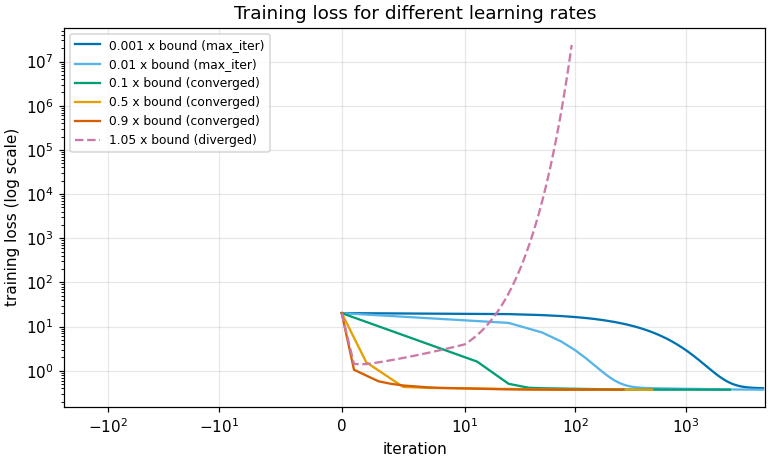

In [12]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plots.plot_lr_sweep(p1))

stop reason : converged
iterations  : 496
final loss  : 0.373581
gradient norm at the end: 9.840952419929274e-07 (tolerance 1e-06 )


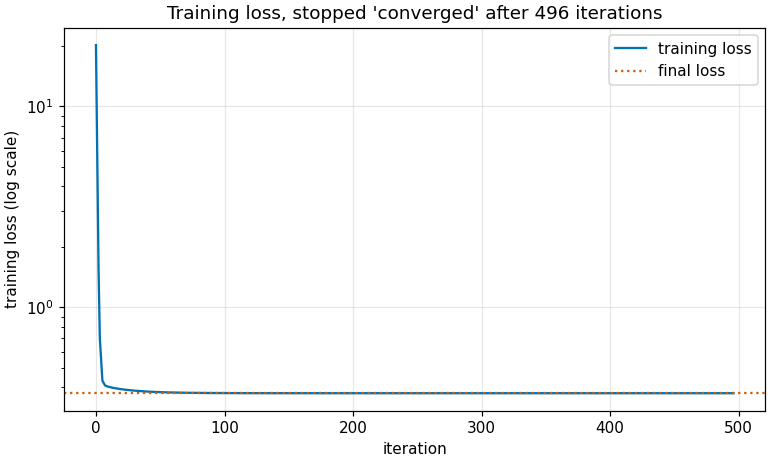

In [13]:
print("stop reason :", p1["stop_reason"])
print("iterations  :", p1["iterations"])
print("final loss  :", round(p1["train_loss_final"], 6))
print("gradient norm at the end:", p1["grad_norm_final"], "(tolerance", p1["tol_grad"], ")")
show(plots.plot_loss_curve(p1))

In [14]:
oracle = p1["oracle"]
print(oracle["label"])
print("largest weight difference:", oracle["max_abs_weight_diff"])
print("loss gap (GD minus exact):", oracle["loss_gap"])
print("validation R2 difference :", oracle["val_r2_diff"])
print("gradient check (max relative error): at zeros", p1["gradient_check_at_zeros"],
      "| at a random point", p1["gradient_check_at_random"])

oracle: np.linalg.lstsq, used only to check GD
largest weight difference: 5.015864552038174e-06
loss gap (GD minus exact): 1.1154355217257717e-11
validation R2 difference : 9.284155666478e-10
gradient check (max relative error): at zeros 7.765467939328136e-07 | at a random point 5.3083114515854556e-08


### Justification: back-transform

The inverse transform of an average is not the average count: without a correction the model's predictions are 0.919 of the true mean on validation. We compared two options, each fitted on the training rows and judged on validation: no factor (R² 0.7278) and a least-squares factor s = Σ(cnt+1)·q / Σq² = 1.069, the single multiplier of q = (λz + 1)^(1/λ) that minimises squared error on bikes (R² 0.7361, mean ratio 0.983). We keep the least-squares factor. In our first pass, with the log target, we also tried Duan's smearing factor, the textbook correction for a log model: it lowered validation R² from 0.718 to 0.696, because the large log-errors sit in quiet night hours while the factor inflates the peaks. Duan's factor is defined for the log only, so it is not in this table. The method is fixed for every later phase; each phase recomputes the factor from its own training residuals.

In [15]:
candidates = pd.DataFrame(p1["backtransform"]["candidates"]).T
candidates.index.name = "method"
print(candidates.round(4).to_string())
print("chosen:", p1["backtransform"]["method"], "with factor", round(p1["backtransform"]["factor"], 4))

        factor  val_mean_ratio  val_r2  val_rmse
method                                          
ls      1.0693          0.9830  0.7361   94.6902
none    1.0000          0.9189  0.7278   96.1509
chosen: ls with factor 1.0693


### Justification: target transform

We fit z = ((cnt + 1)^λ − 1) / λ with λ = 0.1. This family runs from the logarithm (λ → 0) to the raw count (λ = 1); predictions come back to bikes through the inverse, (λz + 1)^(1/λ) − 1.

- **Why not the log.** Our first complete run used `log1p(cnt)` (it is kept in the git history under the tag `v1-submitted`). On the log scale an error of four bikes at 3 am weighs as much as an error of two hundred at 5 pm, but R² on bikes is decided by the busy hours. The log fit spent its effort in the wrong place.
- **Why not the raw count.** At λ = 1 the model is additive in bikes, and the multiplicative structure of the data (a busy hour on a growing system in good weather) is lost: validation R² falls to 0.694.
- **What the table below shows for this phase.** With the Phase 1 design, validation R² is 0.7212 for the log, 0.7361 at λ = 0.1, 0.7414 at 0.2, 0.7416 at 0.3 and 0.7340 at 0.5. Taken alone, this phase would choose λ = 0.3.
- **Why we use 0.1 anyway.** The transform has to be the same in every phase, otherwise Phase 2 could not start from Phase 1's weights. The best exponent shrinks as the model gains structure: a simple model needs a milder transform to make up for what it cannot express, a richer one does not. Our first pass and the pilot fits after it showed that the model the chain ends with prefers about 0.1, so that is the value we fix here, giving up about 0.005 of R² in this phase. Phase 3 checks the exponent again on its target design; if that check disagreed with 0.1 we would have to restart the chain.
- **Honesty note.** This choice was made from a full earlier run, not from this phase alone. We say so because the brief asks for our expectations to be written first: the second-pass Expectation cell above was committed before this run.

       iterations stop_reason  train_r2  val_r2  val_rmse
power                                                    
0.00          474   converged    0.7293  0.7212   97.3189
0.05          485   converged    0.7394  0.7302   95.7299
0.10          496   converged    0.7462  0.7361   94.6902
0.15          507   converged    0.7506  0.7396   94.0566
0.20          518   converged    0.7532  0.7414   93.7259
0.30          540   converged    0.7548  0.7416   93.6934
0.50          585   converged    0.7496  0.7340   95.0559
1.00          699   converged    0.7140  0.6939  101.9651
exponent used (config.yaml): 0.1 | best exponent for this design: 0.3


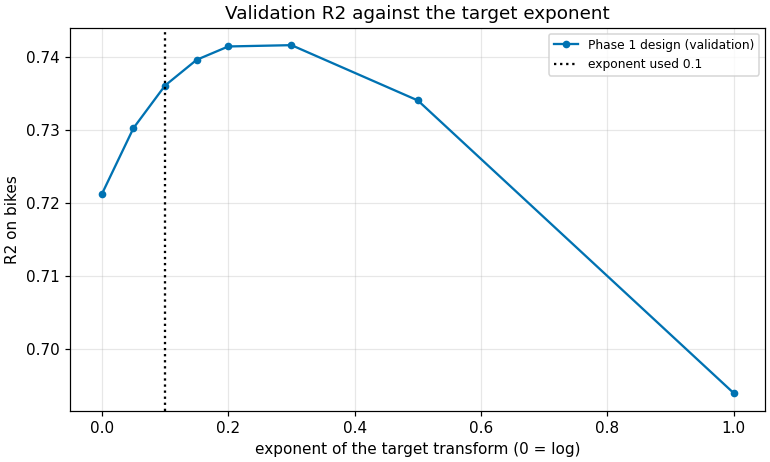

In [16]:
# The same base design fitted by our own gradient descent under each candidate exponent (0 = log, 1 = raw counts).
power_table = pd.DataFrame(p1["target_power_table"]).set_index("power")
print(power_table.round(4).to_string())
print("exponent used (config.yaml):", p1["target_power"], "| best exponent for this design:", p1["target_power_best_here"])
show(plots.plot_target_power(p1))

In [17]:
boot = p1["val_bootstrap"]
scores = pd.DataFrame({"R2": [p1["train_r2"], p1["val_r2"]], "RMSE": [p1["train_rmse"], p1["val_rmse"]],
                       "R2 on the target z": [p1["train_r2_log"], p1["val_r2_log"]]}, index=["train", "validation"])
print(scores.round(4).to_string())
print(f"validation R2 95% interval: [{boot['lo']:.4f}, {boot['hi']:.4f}] (standard error {boot['se']:.4f})")

                R2     RMSE  R2 on the target z
train       0.7462  90.8506              0.8358
validation  0.7361  94.6902              0.8234
validation R2 95% interval: [0.7119, 0.7595] (standard error 0.0123)


In [18]:
ablation = pd.DataFrame(p1["hour_encoding_ablation"]).T[["n_features", "val_r2", "iterations", "stop_reason"]]
ablation.index.name = "hour encoding"
print(ablation.to_string())

              n_features    val_r2 iterations stop_reason
hour encoding                                            
harmonics6            25   0.72936        201   converged
numeric               14  0.260428        201   converged
one_hot             36.0  0.736056        NaN         NaN


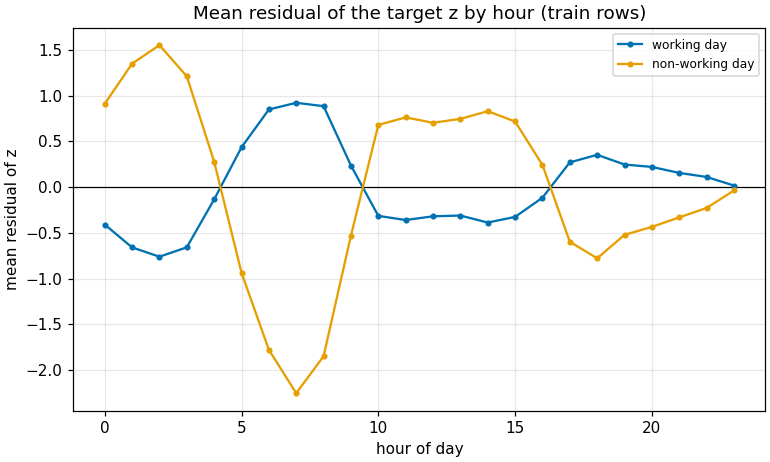

In [19]:
show(plots.plot_residual_profile(p1))

### Justification: bonus

**The operator's cost.** Under-predicting by some amount costs three times as much as over-predicting by the same amount. We read this as a weighted squared error on bikes (the cost is paid in bikes, not on the transformed scale):

L(w) = (1/n) Σ cᵢ (ŷᵢ − yᵢ)², with ŷᵢ = q(xᵢ·w) − 1, q(η) = (λη + 1)^(1/λ), and cᵢ = 3 if ŷᵢ < yᵢ, else 1.

**Gradient.** By the chain rule, ∂ŷᵢ/∂w = q′(ηᵢ)·xᵢ with q′(η) = (λη + 1)^(1/λ − 1) = q(η)^(1−λ), so ∇L = (2/n) Σ cᵢ (ŷᵢ − yᵢ) q(ηᵢ)^(1−λ) xᵢ. (For the log, λ → 0, this is the familiar exp(η)·xᵢ.) The weight cᵢ jumps only where the residual is zero, so it adds nothing to the gradient. Our finite-difference check agrees to 4.7e-09.

**Optimiser.** This loss is no longer a quadratic, so the fixed-step bound of the MSE model does not apply. We keep plain gradient descent but choose each step by backtracking (halve the step until the loss decreases enough), starting from the Phase 1 MSE weights. It stopped as "converged" after 2300 iterations. The absolute-error version of the same cost is shown in the table as a sensitivity check. This model is a side study: Phase 2 receives the MSE weights.

In [20]:
bonus = p1["bonus"]
compare = pd.DataFrame(bonus["val"]).T[["sq_cost", "abs_cost", "under_share", "mean_error", "r2", "rmse", "mean_pred"]]
print(f"asymmetric cost with k = {bonus['k']:g}: {bonus['iterations']} iterations, stop reason {bonus['stop_reason']}")
print("gradient check of the asymmetric loss:", bonus["gradient_check"])
print(compare.round(4).to_string())
print("mean prediction ratio asymmetric / MSE:", round(bonus["mean_shift_ratio"], 4))

asymmetric cost with k = 3: 2300 iterations, stop reason converged
gradient check of the asymmetric loss: 4.702864562588215e-09
               sq_cost  abs_cost  under_share  mean_error      r2     rmse  mean_pred
asym_model  14007.3416  102.7505       0.3090     34.0833  0.7064  99.8598   225.5240
mse_model   22106.7040  140.8221       0.5041    -15.5270  0.7278  96.1509   175.9138
mean prediction ratio asymmetric / MSE: 1.282


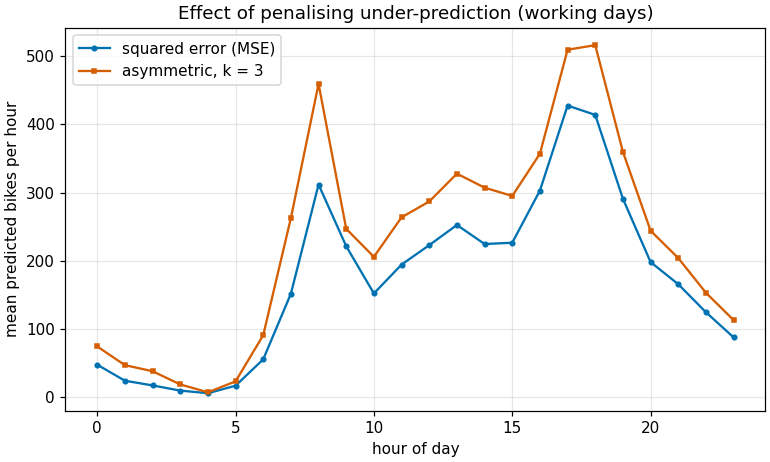

In [21]:
show(plots.plot_bonus_shift(p1))

In [22]:
# The asymmetric loss and its gradient as implemented (src/gd_asym.py).
from src.gd_asym import asym_grad, asym_loss

show_source(asym_loss, asym_grad)

def asym_loss(X, y, w, target: Target, k=3.0, cap=None):
    """L(w) = (1/n) sum_i c_i r_i^2 with r = q(Xw) - 1 - y."""
    r = target.q(_eta(X, w, y, target, cap)) - 1.0 - y
    return float(np.mean(_cost_weights(r, k) * r ** 2))

def asym_grad(X, y, w, target: Target, k=3.0, cap=None):
    """grad L = (2/n) X^T (c * r * dq/deta); shape (p,).

    The chain rule through q gives the dq/deta factor (exp(Xw) for the log). The weight switch has no
    derivative term because r = 0 exactly where c changes.
    """
    eta = _eta(X, w, y, target, cap)
    r = target.q(eta) - 1.0 - y
    return 2.0 / len(y) * (X.T @ (_cost_weights(r, k) * r * target.dq_deta(eta)))



**A control for the bonus.** The comparison above changes two things at once: the bonus model is fitted on bikes
instead of on the transformed scale, *and* it weights under-predictions three times. To separate them we fit the same bike-scale
loss with k = 1 (no asymmetry), from the same starting weights. Fitting on bikes alone already moves the mean
prediction up by a factor 1.089 (a fit on a transformed scale aims near the median, a
bike-scale fit at the mean) and lowers the share of under-predicted hours from
0.50 to 0.43. The asymmetry itself
adds a further factor 1.178 and brings the share down to
0.31. So of the total shift of 1.28, roughly two
thirds is the operator's asymmetry and one third is the change of scale. (The k = 1 model also has the best plain
RMSE of the three, 90.6, for this additive design: squared error on bikes is what
RMSE measures. The table's "MSE model" is the Phase 1 model without a back-transform factor, RMSE
96.2; with the factor it is 94.7.)

In [23]:
from src import bonus_control

control = bonus_control.run(CFG)   # side study: reads artifacts/p1.json, writes artifacts/bonus_control.json
rows = {"Phase 1 (z-scale MSE)": p1["bonus"]["val"]["mse_model"], "bike-scale, k = 1": control["val"]["k1_model"],
        "bike-scale, k = 3": p1["bonus"]["val"]["asym_model"]}
print(pd.DataFrame(rows).T[["sq_cost", "abs_cost", "under_share", "mean_error", "rmse", "mean_pred"]].round(3).to_string())
print("shift from fitting on bikes:", round(control["shift_from_fitting_on_bikes"], 3),
      "| shift from the asymmetry:", round(control["shift_from_asymmetry"], 3),
      "| total:", round(control["total_shift"], 3))

                         sq_cost  abs_cost  under_share  mean_error    rmse  mean_pred
Phase 1 (z-scale MSE)  22106.704   140.822        0.504     -15.527  96.151    175.914
bike-scale, k = 1      17600.131   120.860        0.427       0.042  90.573    191.483
bike-scale, k = 3      14007.342   102.751        0.309      34.083  99.860    225.524
shift from fitting on bikes: 1.089 | shift from the asymmetry: 1.178 | total: 1.282


## Outcome — Phase 1

**What happened.**
- Gradient descent converged in 496 iterations at lr = 0.5064 (λ_max 1.975, as expected close to 2). The weights differ from the closed-form solution by at most 5.0e-06 and the gradient check agrees to 7.8e-07.
- Validation R² is 0.7361 (95% interval 0.712–0.759), RMSE 94.7 bikes; training R² is 0.7462, so there is essentially no gap, as expected for 36 weights. With the log target of our first pass the same model scored 0.7212.
- The residual plot shows the pattern we predicted in both passes: on non-working days the model is far too low at night and too high at commute hours, because it has one hour profile for both day types.
- Bonus: with the 3:1 cost the mean prediction rises by a factor of 1.28; the share of under-predicted validation hours falls from 0.50 to 0.31 and the asymmetric cost from 22107 to 14007, while plain RMSE worsens from 96.2 to 99.9.

**What surprised us.**
- *First pass:* Duan's factor, the textbook correction, was the worst option, and the log target itself turned out to be the main weakness of our whole first chain. We only saw that after Phase 3, which is why there is a second pass.
- *Second pass, expectation met:* validation R² rose to about 0.735 as predicted, the learning rate is unchanged because the design matrix is the same, and the exponent table peaks at 0.3 for this simple model, above the 0.1 we use.
- *Second pass, expectation wrong:* we predicted that the back-transform factor would move closer to 1 with the milder transform. It moved away, to 1.069 from 1.041. Without a factor the predictions are still only 0.92 of the true mean, about the same as with the log, so the milder transform did not reduce the under-shoot of the mean as we had assumed; we do not have a cleaner explanation than that for this additive model.
- The hour as a plain number is still hopeless (R² 0.26): no transform makes a straight line through 0–23 follow a day with two peaks.
- The plain model, read without its factor, under-predicts about half of the hours (0.50) but is -16 bikes low on average: a fit on a transformed scale aims near the median, and the mean of a skewed count is higher. For an operator who fears empty docks the "neutral" model is already biased the wrong way.

**Handed to Phase 2:** the weight vector, the scaler, the target exponent, lr rule and stopping rule in `artifacts/p1.json`.

## Expectation — Phase 2: Polynomial Regression

*Written before running the phase (see the git history of this file).*

**What we do.** We load the Phase 1 weight vector from `artifacts/p1.json`, expand the design, and continue our own gradient descent from those weights (new columns start at zero).

**What we expect, and why.**

1. *The chain.* Because the 35 base columns keep the Phase 1 scaler and every new weight starts at zero, the very first loss of Phase 2 must equal the last loss of Phase 1 to about 1e-9. If it does not, the hand-over is broken.
2. *Which terms matter.* The degree-2 products `workingday × hour` (23 columns) should give by far the largest gain, because they let the hour profile differ between working and non-working days. We expect validation R² to rise from Phase 1's level to about 0.89 from this block alone.
3. *Powers.* Demand rises with temperature and then flattens, and falls with humidity, so squares and cubes of `temp` and `hum` should add a little more (about +0.02). We expect powers of `windspeed` to add nothing measurable. We do not expand `trend`: a power of time would extrapolate badly.
4. *Degree.* We expect the curve of validation R² against degree to flatten after degree 2 or 3; degree 4 should not beat degree 3 by more than 0.001. Our rule, fixed in advance, is to take the smallest degree within 0.001 of the best.
5. *Optimisation.* Powers of a variable are correlated with each other and the interaction columns are correlated with the hour dummies, so the expanded design is worse conditioned. We expect roughly ten times more iterations than Phase 1 (a few thousand) at the same "half the bound" learning rate, still with a monotone loss.
6. *Fit quality.* Training and validation R² should stay within about 0.01 of each other: 60–70 weights are still few for 8,708 rows. If so, this model is more likely under-fit than over-fit, which is the question for Phase 3.

## Expectation — Phase 2, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged.*

1. *The chain* must hold exactly as before: first Phase 2 loss equal to the last Phase 1 loss.
2. *Choices.* We expect the same answers as in the first run: the working-day × hour block carries almost all of the
   gain, degree 3, powers of `temp` only. If the degree or the columns change, it will be by a margin near our 0.001
   tolerance.
3. *Accuracy.* About 0.918 on validation (0.910 with the log target).

### Justification: initialisation from Phase 1
The expanded design keeps the 35 Phase 1 columns in the same positions and with the Phase 1 scaler (read from `artifacts/p1.json`, not refitted). Each new column gets its own training mean and standard deviation. The longer weight vector is the Phase 1 vector with zeros in the new positions. A zero weight switches a column off, so the expanded model starts as exactly the Phase 1 model: its first loss must equal Phase 1's last loss. The cell below checks this to 1e-9. Starting there instead of at random also means gradient descent only has to learn the correction that the new columns allow.

In [24]:
p2 = phase("p2", p2mod.run, upstream="p1", live=True)   # reads artifacts/p1.json and fits Phase 2, here and now
difference = p2["init_loss"] - p1["train_loss_final"]
print("Phase 1 final training loss :", repr(p1["train_loss_final"]))
print("Phase 2 initial loss        :", repr(p2["init_loss"]))
print("difference                  :", difference)
assert abs(difference) <= 1e-9, "the hand-over from Phase 1 to Phase 2 is broken"
print("hand-over check passed (|difference| <= 1e-9)")

p2: computed live just now; largest relative difference to the stored artifact 0.0e+00, 0 other entries differ; stored file kept so that the later phases stay valid
Phase 1 final training loss : 0.3735811984758046
Phase 2 initial loss        : 0.3735811984758046
difference                  : 0.0
hand-over check passed (|difference| <= 1e-9)


In [25]:
# How the Phase 1 weights are placed into the longer Phase 2 vector (src/poly.py).
from src.poly import lift_weights

show_source(lift_weights)

def lift_weights(w_small, names_small, names_big):
    """Place the P1 weights in their slots of the bigger design, zeros elsewhere.

    w_small (p_small,), names_small / names_big are column-name lists.
    Returns w_big (p_big,) with w_big[names_big.index(name)] = w_small[i].
    Because the extra columns start at weight 0, the initial P2 loss equals the final P1 loss.
    """
    slot = {name: j for j, name in enumerate(names_big)}
    missing = [name for name in names_small if name not in slot]
    assert not missing, f"names missing from the big design: {missing}"
    w_big = np.zeros(len(names_big), dtype=np.float64)
    for i, name in enumerate(names_small):
        w_big[slot[name]] = w_small[i]
    return w_big



### Justification: what we expanded
We expand only where Phase 1's residuals showed structure.
- **`workingday × hour` (23 degree-2 products).** The Phase 1 residuals differ by day type at almost every hour. Without this block the expanded model reaches only 0.7499 on validation; with it 0.9178 (ablation below). This is the one expansion that matters.
- **Powers of `temp`.** Demand rises with temperature and flattens when it is hot. At the chosen degree, powers of `temp` alone give 0.9178, adding `hum` gives 0.9181 and adding `windspeed` as well gives 0.9180. Differences below 0.001 are far inside the noise of our validation set (standard error 0.0049), so by our rule we keep the smallest set: `temp` only.
- **Not expanded.** Hour dummies, weather dummies and `holiday` are 0/1, so their powers are themselves. `trend` is not raised to a power, because a polynomial in time bends away sharply outside the observed dates. The day-of-year terms are already non-linear.

In [26]:
print("blocks      :", p2["blocks"])
print("power cols  :", p2["power_cols"])
print("columns     :", len(p2["feature_names"]), "(", len(p2["expanded_feature_names"]), "new )")
print("new columns :", ", ".join(p2["expanded_feature_names"][:6]), "...")
print("lambda_max  :", round(p2["lambda_max"], 4), "| lr:", round(p2["lr"], 4),
      "| condition number:", round(p2["condition_number"], 1))

blocks      : ['wd_x_hr']
power cols  : ['temp']
columns     : 61 ( 25 new )
new columns : temp^2, temp^3, workingday*hr_1, workingday*hr_2, workingday*hr_3, workingday*hr_4 ...
lambda_max  : 2.7396 | lr: 0.365 | condition number: 64.2


### Justification: degree
"Degree" is the highest total degree of any term: the interaction products are degree 2 and the powers go up to the chosen degree. With every candidate fitted by our own gradient descent from the Phase 1 weights, validation R² is 0.9045 at degree 1 (interactions only), 0.9144 at degree 2, 0.9180 at degree 3 and 0.9180 at degree 4. Our rule, fixed before the run, is the smallest degree within 0.001 of the best: degree 3. The square captures "warmer is better", the cube captures the flattening at high temperature; a fourth power adds nothing. The learning rate is again half the stability bound, recomputed for this design (λ_max 2.740, lr 0.3650), with the same stopping rule as Phase 1.

In [27]:
rows = pd.DataFrame(p2["degree_sweep"])[["degree", "n_features", "iterations", "stop_reason", "train_r2", "val_r2"]]
print(rows.round(4).to_string(index=False))
print("chosen degree:", p2["degree"], "(smallest within", p2["plateau_tol"], "of the best validation R2)")

 degree  n_features  iterations stop_reason  train_r2  val_r2
      1          59         458   converged    0.9055  0.9045
      2          62         494   converged    0.9176  0.9144
      3          65         697   converged    0.9216  0.9180
      4          68         815   converged    0.9219  0.9180
chosen degree: 3 (smallest within 0.001 of the best validation R2)


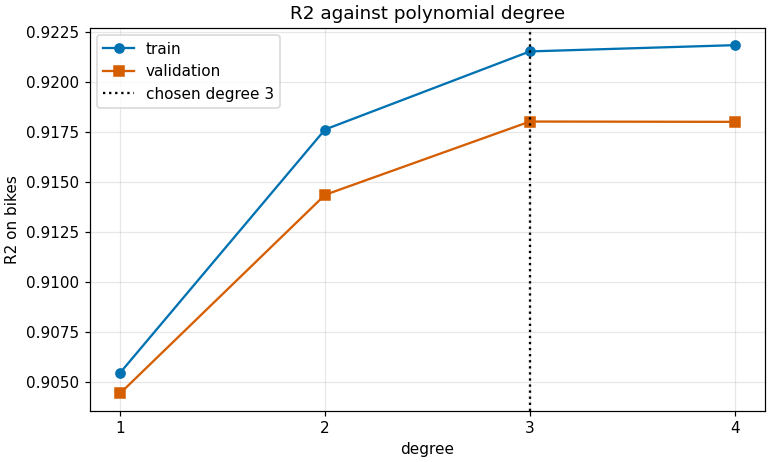

In [28]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plots.plot_degree_sweep(p2))

In [29]:
cols = pd.DataFrame(p2["power_col_sweep"])[["power_cols", "n_features", "iterations", "stop_reason", "train_r2", "val_r2"]]
cols["power_cols"] = cols["power_cols"].apply(lambda c: ", ".join(c))
print(cols.round(4).to_string(index=False))
print("chosen power columns:", p2["power_cols"])

          power_cols  n_features  iterations stop_reason  train_r2  val_r2
                temp          61         636   converged    0.9206  0.9178
           temp, hum          63         668   converged    0.9218  0.9181
temp, hum, windspeed          65         697   converged    0.9216  0.9180
chosen power columns: ['temp']


In [30]:
ablation = p2["block_ablation"]["without_wd_x_hr"]
print("without the workingday x hour block:", ablation["n_features"], "columns, validation R2",
      round(ablation["val_r2"], 4), "(train", round(ablation["train_r2"], 4), ")")
print("with the block                     :", len(p2["feature_names"]), "columns, validation R2",
      round(p2["val_r2"], 4), "(train", round(p2["train_r2"], 4), ")")

without the workingday x hour block: 38 columns, validation R2 0.7499 (train 0.7612 )
with the block                     : 61 columns, validation R2 0.9178 (train 0.9206 )


In [31]:
paired = p2["paired_vs_p1"]
boot = p2["val_bootstrap"]
final = pd.DataFrame({"R2": [p1["val_r2"], p2["val_r2"]], "RMSE": [p1["val_rmse"], p2["val_rmse"]]},
                     index=["Phase 1", "Phase 2"])
print(final.round(4).to_string())
print(f"Phase 2 validation R2 95% interval: [{boot['lo']:.4f}, {boot['hi']:.4f}]")
print(f"gain over Phase 1: {paired['delta']:.4f}, paired 95% interval [{paired['lo']:.4f}, {paired['hi']:.4f}]")
print("stop reason:", p2["stop_reason"], "after", p2["iterations"], "iterations; oracle max weight difference:",
      p2["oracle"]["max_abs_weight_diff"])

             R2     RMSE
Phase 1  0.7361  94.6902
Phase 2  0.9178  52.8411
Phase 2 validation R2 95% interval: [0.9081, 0.9272]
gain over Phase 1: 0.1817, paired 95% interval [0.1608, 0.2056]
stop reason: converged after 636 iterations; oracle max weight difference: 4.771163032463166e-06


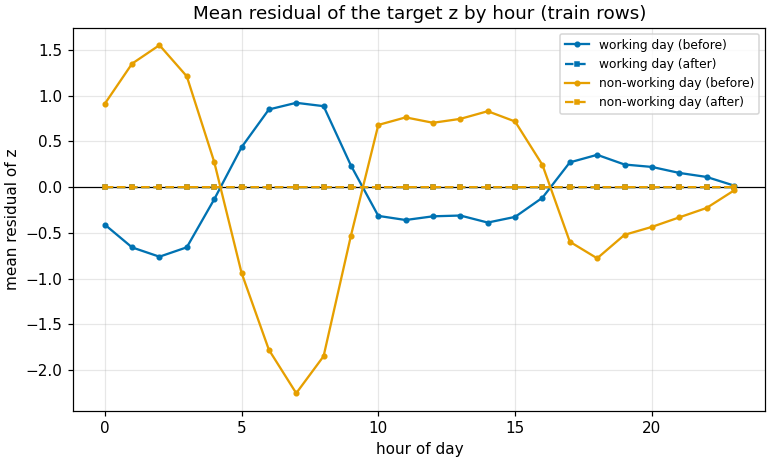

In [32]:
show(plots.plot_residual_profile(p1, p2))

## Outcome — Phase 2

**What happened.**
- The hand-over held exactly: the first Phase 2 loss equals the last Phase 1 loss (0.373581).
- Chosen model: degree 3, powers of `temp`, plus `workingday × hour`: 61 weights. Validation R² rose from 0.7361 to 0.9178 (gain 0.182, paired 95% interval 0.161–0.206); RMSE is 52.8 bikes. Training R² is 0.9206: still no gap.
- As expected, almost all of the gain is the interaction block (degree 1 with interactions already gives 0.9045); the temperature powers add about 0.02, and the curve is flat after degree 3.
- The residual profile by hour and day type is now flat.

**What surprised us.**
- Optimisation was much easier than we feared: 636 iterations, not thousands. We had expected the new columns to be strongly correlated with the old ones, but because we build powers and products from standardised columns the condition number only rose to 64.
- Humidity powers were not worth keeping (0.9178 → 0.9181); we had expected humidity to need a curve as much as temperature does.
- Training and validation R² are almost identical. A model that fits unseen rows as well as its own training rows is not over-fit; the open question for Phase 3 is whether it is still too simple.

**Second pass.** With the power target the choices are the ones we expected: the same block, the same degree, powers of `temp` only, and validation R² 0.9178 against 0.9105 with the log target. One detail differs from the first pass: the degree curve is not quite as flat before degree 3 (0.9144 at degree 2, 0.9180 at degree 3), so the cube of temperature earns its place more clearly now.

**Handed to Phase 3:** degree 3 and the expanded feature list in `artifacts/p2.json`.

## Expectation — Phase 3: Bias–Variance Tradeoff

*Written before running the phase (see the git history of this file).*

**What we do.** We take the Phase 2 design (its degree and feature list, loaded from `artifacts/p2.json`) as the anchor and move complexity both below and above it on a nested ladder of ten designs, from "no hour information" (13 weights) up to "month × working day × hour" (about 900 weights). We also vary the pure polynomial degree, and the amount of training data. Every design is scored three ways: on our seeded validation set, on whole held-out days inside the training portion, and on one chronological split (train before 1 July 2012, validate after).

**What we expect, and why.**

1. *Phase 2 is not over-fit.* Its training and validation R² should differ by less than 0.01. If anything we expect it to be slightly under-fit: letting the weather effect depend on the hour should still raise validation R² by 0.01–0.02.
2. *Degree alone will look flat.* Raising the power of temperature and humidity from 3 to 8 should move neither curve by more than 0.002. A flat line is not evidence of a good fit, which is why we need the wider ladder.
3. *Variance appears late.* On the ladder we expect validation R² to peak somewhere around 250–450 weights and then fall while training R² keeps rising. The first clearly harmful levels should be the month × hour blocks, where many cells hold only a handful of training rows.
4. *Learning curves.* At Phase 2 complexity, validation R² should stop improving after roughly half the training days (a bias signature). At the top of the ladder the train–validation gap should be visibly wider with little data and shrink as data is added (a variance signature).
5. *The time question.* We expect the seeded estimate and the held-out-day estimate to be almost equal (within 0.005). Our model has no way to memorise a particular day, so sharing days between training and validation should hardly help it. The chronological estimate should be clearly lower, by 0.04–0.08, because the model has to extrapolate a growth trend into six months it has never seen, having observed July–December only once.
6. *Which estimate to trust.* For the hidden test set, which is the 20th of each month and so lies inside the observed period, the held-out-day estimate is the right one. For genuinely future months the chronological estimate is the honest one. We expect the diagnosis to stay "bias first, variance only at the top of the ladder" under all three, but the chronological split should prefer a simpler model than the seeded split does, especially disliking the blocks that let the trend vary by hour.

## Expectation — Phase 3, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged; the ladder now has
eleven levels because level C6 was added during the first pass.*

1. *Diagnosis.* Unchanged in kind: Phase 2 under-fit, target at level C6, variance only at the top of the ladder.
2. *The time question.* This is where we expect the real change. With the log target the chronological estimate of the
   target was about 0.91 against 0.94 on held-out days. A straight trend on the log scale is exponential growth; on the
   λ = 0.1 scale it grows more slowly, so the overshoot in the later months should shrink and the chronological
   estimate should rise to about 0.93 to 0.94, almost closing the gap.
3. *Held-out days.* A smaller gain, about +0.003 to +0.004 for the target.
4. *Exponent check.* A new table scores the target design for several exponents. We expect a flat optimum around 0.1
   on validation and held-out days, with 0.15 to 0.2 slightly better chronologically. If the best exponent were far
   from the one Phase 1 used, our chain would be inconsistent and we would have to start again.

### Justification: what we varied

- **A ladder of nested designs, anchored at Phase 2.** Level C3 is exactly the Phase 2 design, read from `artifacts/p2.json`. Below it we remove what Phase 2 added (C2: no powers; C1: no interactions; C0: no hour at all). Above it we add blocks: weather effects that depend on the hour (C4), a separate hour profile for each weekday (C5), weather detail and weather memory (C6, see the note below), finer weather interactions (C7), hour-specific season and trend (C8), and finally month × hour and month × day type × hour (C9, C10), where many cells contain only a few training rows. Bias shows as "training and validation both low, both rise when we add a block"; variance shows as "training keeps rising, validation falls".
- **The degree alone**, from 1 to 8, with everything else as in Phase 2, because the task asks about the degree; we expected this axis to be flat.
- **The amount of training data** (10% to 100% of the training days) for the anchor, the target and the top level: more data cures variance but not bias.
- **Three ways of scoring** each design: the seeded validation set; five folds of whole held-out days inside the training portion (folds are fixed by the calendar, not by a random seed); and one chronological split.
- **How the sweeps are fitted.** These several hundred fits use the closed-form least-squares solution, which our gradient descent reaches to within 1e-5 in Phases 1 and 2 (the chain cell below checks it again on the anchor); the largest levels would need tens of thousands of iterations each. A tiny ridge term (1e-8) keeps the solution defined where columns are exact copies of each other (`holiday` is determined by the weekday dummies and `workingday`).
- **Note on level C6.** This level was not in our first ladder. After the first complete run we looked at where the C5 model's errors were (working-day rush hours and rainy hours carried about half and a fifth of the squared error) and added the terms that address them: squares and cubes of humidity, wind terms, a temperature effect per working-day hour, and the weather situation one hour earlier and the worst of the previous three hours (wet roads keep riders away after the rain has stopped). These last columns use the weather of neighbouring rows, never their counts. Because this level was designed after looking at validation errors, we judge it mainly by the two estimates that were not used to design it.

In [33]:
# Phase 3 runs everything from artifacts/p1.json and artifacts/p2.json; CFG comes from the setup notebook.
import pandas as pd

from src.common import load_config, read_artifact
from src.phases import p3 as p3mod
from src.plots_p3 import plot_degree_axis, plot_ladder, plot_learning_curves, plot_three_estimates

p3 = phase("p3", p3mod.run, upstream="p2", live=True)  # runs Phase 3 here and now (about 15 seconds)

p3: computed live just now; largest relative difference to the stored artifact 0.0e+00, 0 other entries differ; stored file kept so that the later phases stay valid


In [34]:
# The chain: the anchor is exactly the Phase 2 design, and our closed-form fit must reproduce its validation R2.
p2 = read_artifact("p2")
print("Phase 2 degree:", p2["degree"], "| features (with bias):", len(p2["feature_names"]))
print("Phase 2 power columns:", p2["power_cols"], "| blocks:", p2["blocks"])
print("Phase 2 validation R2 (gradient descent):", round(p2["val_r2"], 5))
print("anchor validation R2 (closed form here): ", round(p3["ladder"][p3["anchor"]["anchor_index"]]["seeded"]["r2"], 5))
print("anchor_check (closed form - gradient descent):", f"{p3['anchor_check']:.2e}")
print("back-transform method reused from Phase 1:", p3["back_method"])

Phase 2 degree: 3 | features (with bias): 61
Phase 2 power columns: ['temp'] | blocks: ['wd_x_hr']
Phase 2 validation R2 (gradient descent): 0.9178
anchor validation R2 (closed form here):  0.9178
anchor_check (closed form - gradient descent): -3.87e-08
back-transform method reused from Phase 1: ls


In [35]:
# Complexity ladder: three validators per level.
ladder = pd.DataFrame([{"level": r["name"], "weights": r["n_features"], "train_r2": r["seeded"]["train_r2"],
                        "seeded_r2": r["seeded"]["r2"], "gap": r["gap_seeded"], "day_block_r2": r["day_block"]["r2"],
                        "day_block_sd": r["day_block"]["sd"], "chrono_r2": r["chrono"]["r2"]} for r in p3["ladder"]])
print(ladder.round(4).to_string(index=False))
print("target level:", p3["target_level"], "| best on held-out days:", p3["best_level_day_block"],
      "| best chronologically:", p3["best_level_chrono"], "| over-fit from level:", p3["overfit_from_level"])

              level  weights  train_r2  seeded_r2    gap  day_block_r2  day_block_sd  chrono_r2
         C0_no_hour       13    0.2560     0.2415 0.0145        0.2496        0.0278     0.1264
        C1_additive       36    0.7462     0.7361 0.0101        0.7439        0.0114     0.6436
         C2_wd_x_hr       59    0.9055     0.9045 0.0010        0.9032        0.0115     0.8369
          C3_phase2       61    0.9206     0.9178 0.0028        0.9180        0.0132     0.8941
    C4_hr_x_weather      107    0.9285     0.9259 0.0026        0.9249        0.0135     0.9123
    C5_weekday_x_hr      251    0.9381     0.9346 0.0035        0.9327        0.0112     0.9202
  C6_weather_detail      282    0.9506     0.9413 0.0093        0.9462        0.0077     0.9378
    C7_fine_weather      332    0.9513     0.9407 0.0106        0.9459        0.0073     0.9283
       C8_hr_x_time      401    0.9520     0.9418 0.0101        0.9458        0.0077     0.9041
      C9_month_x_hr      665    0.9534  

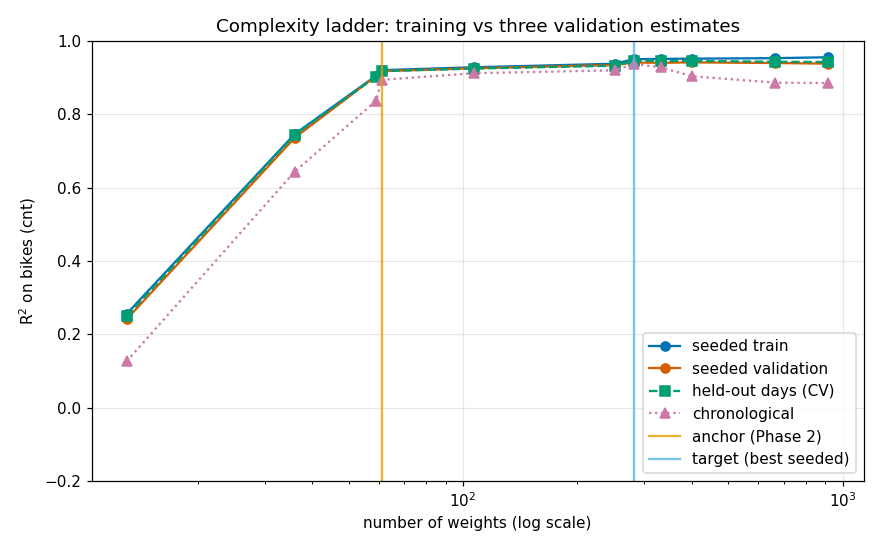

In [36]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_ladder(p3))

In [37]:
# Degree axis: anchor blocks and power columns fixed, only the degree changes.
degrees = pd.DataFrame([{"degree": r["degree"], "weights": r["n_features"], "train_r2": r["seeded"]["train_r2"],
                         "seeded_r2": r["seeded"]["r2"], "day_block_r2": r["day_block"]["r2"],
                         "chrono_r2": r["chrono"]["r2"]} for r in p3["degree_axis"]])
print(degrees.round(4).to_string(index=False))
print("range of seeded R2 over degrees >= 2:", round(p3["diagnosis"]["degree_axis_range"], 5))

 degree  weights  train_r2  seeded_r2  day_block_r2  chrono_r2
      1       59    0.9055     0.9045        0.9032     0.8369
      2       60    0.9157     0.9137        0.9131     0.8729
      3       61    0.9206     0.9178        0.9180     0.8941
      4       62    0.9210     0.9174        0.9183     0.8994
      5       63    0.9210     0.9170        0.9183     0.8995
      6       64    0.9211     0.9170        0.9184     0.8990
      8       66    0.9212     0.9170        0.9181     0.8946
range of seeded R2 over degrees >= 2: 0.00414


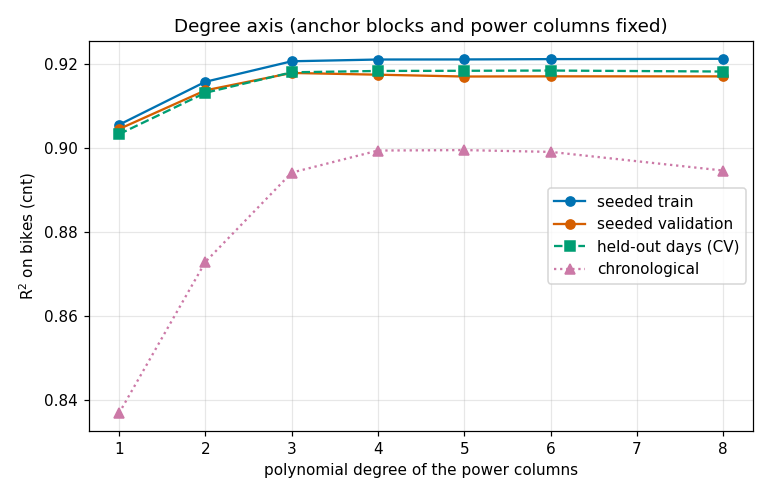

In [38]:
show(plot_degree_axis(p3))

In [39]:
# Learning curves for the anchor, the target and the top of the ladder (clipped at R2 = -0.2 in the plot).
curves = pd.DataFrame([{"design": key, **c} for key, curve in p3["learning_curves"].items() for c in curve])
print(curves.round(4).to_string(index=False))

design  fraction  n_days  n_rows  train_r2   val_r2
anchor       0.1      46     873    0.8955   0.9090
anchor       0.2      91    1729    0.8958   0.9118
anchor       0.4     182    3441    0.9096   0.9175
anchor       0.6     274    5210    0.9133   0.9170
anchor       0.8     365    6939    0.9189   0.9173
anchor       1.0     456    8708    0.9206   0.9178
target       0.1      46     873    0.9414   0.8971
target       0.2      91    1729    0.9360   0.9200
target       0.4     182    3441    0.9391   0.9336
target       0.6     274    5210    0.9450   0.9388
target       0.8     365    6939    0.9480   0.9401
target       1.0     456    8708    0.9506   0.9413
   top       0.1      46     873    0.9887 -15.8645
   top       0.2      91    1729    0.9621   0.4979
   top       0.4     182    3441    0.9520   0.9094
   top       0.6     274    5210    0.9531   0.9272
   top       0.8     365    6939    0.9545   0.9341
   top       1.0     456    8708    0.9558   0.9384


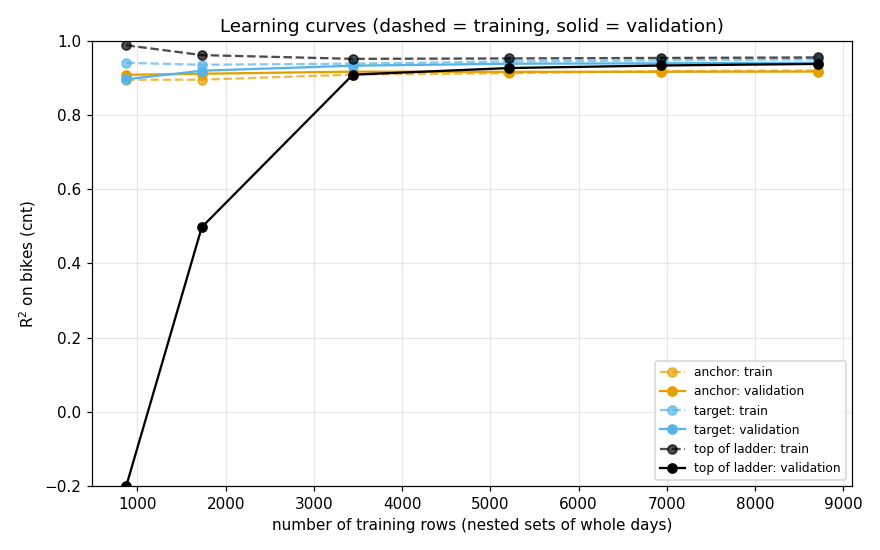

In [40]:
show(plot_learning_curves(p3))

### Justification: the chronological cut

We train on every date before 2012-07-01 (8151 rows) and validate on every date from then on (2735 rows, about a quarter of the file). We put the cut there for three reasons: the held-out part is about the same size as our seeded validation set, so the two estimates are comparably precise; it covers half a seasonal cycle (summer to winter) instead of one season; and the training part still contains one full year plus the first half of the second, so the model has seen each month at least once. A later cut would test only autumn and winter; an earlier one would leave too little of 2012 to learn the growth from.

In [41]:
# Three estimates for the anchor and the target, their gaps, and the bootstrap interval of the seeded estimate.
rows = []
for label, est, gaps in (("anchor", p3["estimates"], p3["gaps"]["anchor"]),
                         ("target", p3["estimates_target"], p3["gaps"]["target"])):
    rows.append({"design": label, "seeded": est["seeded"]["r2"], "ci_lo": est["seeded"]["lo"],
                 "ci_hi": est["seeded"]["hi"], "day_holdout": est["day_holdout"]["r2"],
                 "day_sd": est["day_holdout"]["sd"], "chrono": est["chrono"]["r2"],
                 "leakage_gap": gaps["leakage"], "drift_gap": gaps["drift"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print("paired gain target - anchor (seeded):", {k: round(v, 4) for k, v in p3["paired_target_vs_anchor"].items()})

design  seeded  ci_lo  ci_hi  day_holdout  day_sd  chrono  leakage_gap  drift_gap
anchor  0.9178 0.9081 0.9272       0.9180  0.0132  0.8941      -0.0002     0.0239
target  0.9413 0.9332 0.9489       0.9462  0.0077  0.9378      -0.0049     0.0084
paired gain target - anchor (seeded): {'delta': 0.0235, 'hi': 0.0298, 'lo': 0.0177}


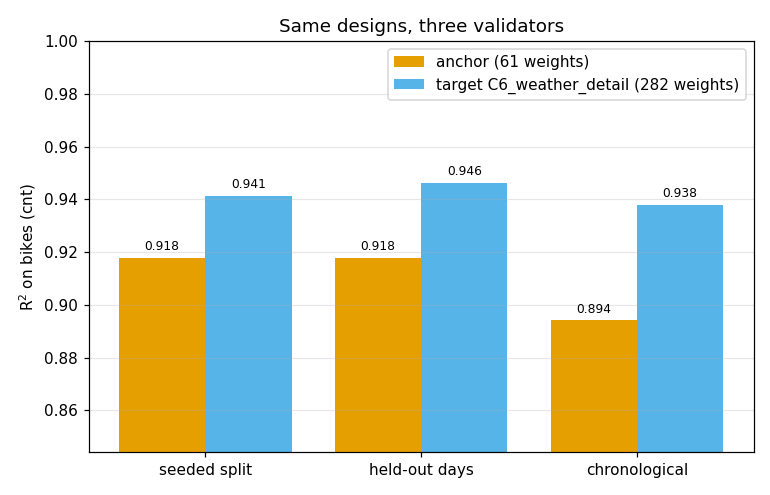

In [42]:
show(plot_three_estimates(p3))

### Justification: which estimate to trust

- **The gap has two possible causes, and we measured them separately.** Seeded versus held-out days isolates the effect of sharing days between training and validation: -0.0002 for the Phase 2 model and -0.0049 for the target (a negative number means held-out days score higher), both smaller than the spread between day folds (0.013). Held-out days versus chronological isolates what changes when the validation period lies in the future: 0.024 and 0.008.
- **So what gap there is, is drift, not leakage.** In the late period the mean demand is 262 bikes against 168 before the cut, and the Phase 2 model's predictions there are 1.08 times the true mean: a straight trend on the transformed scale still extrapolates growth too steeply. If we only correct that level (a diagnostic, not a usable score) R² rises to 0.909, so most of the gap is the level and the hourly shape still fits.
- **Which one to trust.** For data from new time periods, the chronological estimate (0.894 for Phase 2, 0.938 for the target) is the honest one, and it is the number we would quote to an operator planning next year. The seeded number is the easiest to flatter. For our hidden test set specifically, which is the 20th of each month inside the two observed years, the held-out-day estimate is the closest match.
- **Does it change the diagnosis?** No in kind, yes in degree: see the Outcome.

In [43]:
# Chronological detail: the late period has a much higher level of demand (growth) than the early one.
detail = pd.DataFrame(p3["chrono_detail"]).T
print(detail.to_string())
print("r2_level_corrected rescales late predictions by the late period's own mean: a diagnostic of level drift only, "
      "not a usable estimate.")

          cut_date mean_cnt_early mean_cnt_late mean_ratio n_early n_late        r2 r2_level_corrected       rmse
anchor  2012-07-01     167.785793     262.46947   1.081574    8151   2735    0.8941            0.90897  70.340668
target  2012-07-01     167.785793     262.46947   1.062411    8151   2735  0.937835           0.944652  53.892916
r2_level_corrected rescales late predictions by the late period's own mean: a diagnostic of level drift only, not a usable estimate.


In [44]:
# How much variance is left once the design cells are fully known? (an optimistic ceiling)
for key, value in p3["noise_floor"].items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

n_cells: 2636
noise_floor_r2: 0.9547
noise_floor_r2_adjusted: 0.9350
singleton_cell_share: 0.2986
singleton_row_share: 0.0904


In [45]:
# Diagnosis and target complexity.
for key, value in p3["diagnosis"].items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")
target = p3["target_complexity"]
print("target:", target["level"], "| weights:", target["n_features"], "| degree:", target["degree"],
      "| power columns:", target["power_cols"])
print("blocks:", target["blocks"])

anchor_gap_train_val: 0.0028
chrono_gain: 0.0437
day_block_gain: 0.0283
degree_axis_range: 0.0041
gain_ci_hi: 0.0298
gain_ci_lo: 0.0177
gain_target_over_anchor: 0.0235
label: under-fit
overfit_from_level: 10
target: C6_weather_detail | weights: 282 | degree: 3 | power columns: ['temp']
blocks: ['wd_x_hr', 'hr_x_temp', 'hr_x_hum', 'wk', 'wk_x_hr', 'wx_detail', 'wd_x_hr_x_temp', 'ws_memory']


### Justification: exponent check

Phase 1 fixed the exponent of the target transform at 0.1 for the whole chain, on the strength of an earlier run. Here we test that decision on the design this phase selects: the table and plot below refit the target design for each candidate exponent. On validation the best is 0.1; the neighbours score 0.9410 (0.05), 0.9413 (0.1) and 0.9405 (0.15), against 0.9390 for the log and 0.9231 for the square root. Held-out days agree (0.9426 for the log, 0.9462 at 0.1). The chronological split would like a slightly larger exponent (0.938 at 0.1, 0.941 at 0.15, 0.941 at 0.2) and dislikes the log most (0.914). Our consistency test is whether the exponent in use is within 0.001 validation R² of the best one: it is (True), so the chain does not have to be restarted. We do not move to 0.15 for the chronological gain: the exponent is tuned on the validation set like every other choice, and 0.1 is the best there.

       chrono_r2  day_block_r2  seeded_r2
power                                    
0.00      0.9141        0.9426     0.9390
0.05      0.9297        0.9453     0.9410
0.10      0.9378        0.9462     0.9413
0.15      0.9411        0.9459     0.9405
0.20      0.9412        0.9448     0.9390
0.30      0.9356        0.9411     0.9345
0.50      0.9148        0.9310     0.9231
1.00      0.8439        0.8974     0.8879
exponent used: 0.1 | best seeded R2 at: 0.1 | consistent within the plateau tolerance: True


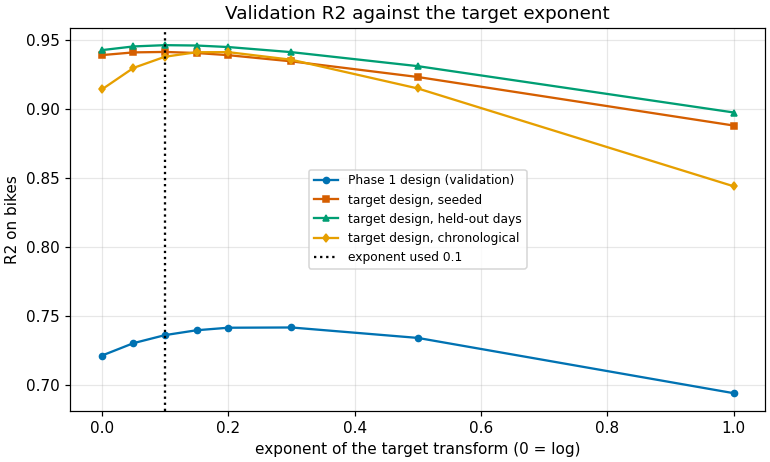

In [46]:
# The target design in closed form under each candidate exponent (the chain itself uses the exponent from Phase 1).
exponents = pd.DataFrame(p3["target_power_check"]).set_index("power")
print(exponents.round(4).to_string())
print("exponent used:", p3["target_power_used"], "| best seeded R2 at:", p3["target_power_best_seeded"],
      "| consistent within the plateau tolerance:", p3["target_power_consistent"])
show(plots.plot_target_power(read_artifact("p1"), p3))

### Justification: target complexity

Rule: the simplest ladder level whose seeded validation R² is within 0.001 of the best level. It selects C6_weather_detail (282 weights): validation R² 0.9413 against 0.9346 one level below and 0.9407 one level above. The other two estimates agree: held-out days 0.9327 → 0.9462 → 0.9459, chronological 0.920 → 0.938 → 0.928.

We have to be open about two things. First, our original rule was "the level with the highest validation R²". On the first ladder it picked a level 140 weights larger than its neighbour on a difference of 0.0005, which is not a rule we could defend, so we replaced it with the same "smallest within 0.001 of the best" rule we had already fixed for the degree in Phase 2. Second, level C6 itself was added after that first run (see the note above). Both changes are in the git history, and the rule still looks only at the seeded validation set.

## Outcome — Phase 3

**Diagnosis: the Phase 2 model is under-fit (high bias, no measurable variance).**
- Its training and validation R² differ by 0.0028. A model that scores the same on rows it has and has not seen is not over-fit.
- Adding structure raises validation R² from 0.9178 to 0.9413: a gain of 0.023 with a paired 95% interval of 0.018–0.030, confirmed on held-out days (+0.028) and on the chronological split (+0.044). Something real was missing.
- The Phase 2 learning curve is nearly flat: with 10% of the training days validation R² is already 0.909, with all of them 0.918. More data does little for a model that is too simple.
- Variance does exist, but only at the top of the ladder: from level 10 on, training R² keeps rising (0.9558 at C10) while validation falls (0.9384); the chronological score starts falling much earlier, right after the target (0.938 at C6, 0.904 at C8, 0.886 at C10).
- The target itself shows a small gap (training 0.9506, validation 0.9413) and its learning curve is still rising at full size (0.940 with 80% of the days, 0.941 with all). That is where a little variance begins, and it is what Phase 4 has to watch.

**The time question.** Seeded 0.918, held-out days 0.918, chronological 0.894 for Phase 2; 0.941 / 0.946 / 0.938 for the target. Sharing days between training and validation is worth nothing to these models; what gap there is comes from drift, the later months having a higher level of demand than the trend predicts. We trust the chronological number for future periods. It does not change the diagnosis, the simpler models are worse on every split, but it does change how far we go: it is the split that punishes the levels above the target most clearly, so it supports stopping there.

**What surprised us.**
- *First pass:* we expected sharing days between training and validation to matter at least a little. It does not. The warning in the task statement is right in general, but a linear model with a few hundred weights has no way to recognise an individual day. (A tree model we tried outside the pipeline does: it scores 0.966 on the seeded split and 0.950 on held-out days. The leakage is real; our model class is simply too stiff to use it.)
- *First pass:* the degree axis moved validation R² by only 0.0041 between degree 2 and 8. Had we varied only the degree we would have concluded "reasonably fit" and missed 0.023 of R². Our own first selection rule failed on a near-tie, and our first ladder stopped one useful level short.
- *Second pass, expectation met:* the diagnosis and the target level are unchanged, and the exponent check confirms 0.1.
- *Second pass, better than expected:* we predicted the chronological estimate of the target would rise from 0.914 to about 0.93–0.94. It is 0.938, and the gap between held-out days and the chronological split shrank from 0.028 to 0.008. With the log, the model over-shot the later months by a factor 1.11; now by 1.06. Most of what we had called "drift" in the first pass was our own choice of target: a straight line on the log scale is exponential growth.
- *Second pass:* the gain on held-out days is the modest one we expected (0.9426 → 0.9462).

**How much is left.** Averaging `cnt` over cells of year, month, day type, hour and weather situation explains 0.935 of the training variance after adjusting for the number of cells; our target is above that benchmark on unseen rows. The diagnostic tree model mentioned above (`exp/v2/`, never used for any prediction we submit) scored about 0.950 on held-out days and about 0.90 chronologically, so the target (0.946 and 0.938) is within about 0.004 of a far more flexible model on unseen days and clearly ahead of it on unseen months. In a second exploration round we tried twenty more groups of input-only features on top of the target (daylight by hour, earlier temperature and humidity, rain in the last six hours, more hour × weather products, and others). None improved held-out days by more than 0.001, and the only ones that did anything, separate levels for each calendar month of each year, gained 0.003 on held-out days and lost 0.05 chronologically. We stop adding structure here.

**Handed to Phase 4:** diagnosis "under-fit", target complexity C6_weather_detail with 282 weights (degree 3). The model we carry forward is not over-fit, but it is the first one with a visible train–validation gap, so we expect regularization to act as insurance with at most a small gain; Phase 4 tests that, including on the over-fit top level.

## Expectation — Phase 4: Regularization (L1, L2, Elastic Net)

*Written before running the phase (see the git history of this file).*

**What we do.** We load the target complexity from `artifacts/p3.json`, add back the six columns we had kept out for conditioning reasons (`atemp`, `yr`, `instant`, `season`, `mnth`, `weekday`), and fit Ridge, Lasso and Elastic Net with our own solvers on exactly the same standardised design, the same training rows and the same grid density. For each method we pick the penalty by validation R² and then check that choice on held-out days and on the chronological split. Finally we judge every original column with drop tests, lasso selection frequency and correlations.

**What we expect, and why.**

1. *Regularization will be a robustness choice, not an accuracy one.* Phase 3 should hand us a model that is not over-fit, so we expect the best penalties to be small and all three methods to land within about ±0.002 validation R² of the unpenalised fit, which is inside the bootstrap noise. We do not expect any method to "win" clearly.
2. *Lasso will not be very sparse.* The signal here is spread over many hour-specific columns. We expect Lasso at its best penalty to keep well over half of the coefficients.
3. *Lasso will be unreliable on duplicates.* `temp` and `atemp` are correlated at 0.985. We expect Lasso to keep both at small penalties, or to pick one of them arbitrarily, and Elastic Net to share the weight between them. This is why a zero from Lasso is only one piece of evidence for us, next to the drop tests and the selection frequency over resampled days.
4. *Where the penalty should matter.* On the most complex ladder level, which Phase 3 should show to be over-fit, we expect a penalty to recover most of the lost validation R², but not to beat the target design by more than the noise.
5. *Column verdicts we predict.* Useful: `hr`, `temp`, `hum`, `weathersit`, and the day-type information. Redundant: `atemp` (carried by `temp`), `season` and `mnth` (carried by the day-of-year terms from `dteday`), `yr` and `instant` (carried by the trend from `dteday`), and at least one of `weekday` / `workingday` / `holiday`, since `workingday` is an exact function of the other two. We are least sure about `windspeed` and `holiday`: their effect may be too small to separate from noise, in which case the honest verdict is "uninformative".
6. *Surprise we are watching for.* If dropping a column we believe to be useful costs nothing, another column is carrying its information and we have the labels the wrong way round.

## Expectation — Phase 4, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged.*

1. *Regularization* should again be insurance: three methods tied within noise, tiny penalties, Lasso not sparse.
2. *Verdicts* should be the same as in the first pass, with one candidate for a flip: `windspeed` was useful by a
   small margin and could fall back to uninformative.
3. *Final model.* About 0.941 on validation, 0.946 on held-out days and 0.93 to 0.94 chronologically.

### Justification: search ranges and strategy

- **How Phase 3 shapes the search.** The diagnosis was "under-fit, no measurable variance" for the model we carry forward. So we do not expect a large penalty to help, and the grid has to reach down to practically zero to show that; we also add the unpenalised fit as a reference line. At the other end the grid must go far enough to show the model being destroyed. If a method's best penalty turns out to be the smallest value on its grid, we read that as "no penalty wanted" and say so, rather than as a finding about that particular value.
- **Design.** The Phase 3 target design plus the columns we had held back (`atemp`, `yr`, `instant`, `season`, `mnth`; `weekday` is already in the target), so that every original column is in front of the three methods. All columns are standardised on the training rows; the intercept is never penalised.
- **Objective.** (1/2n)‖y − b − Xw‖² + α·ρ‖w‖₁ + (α/2)(1 − ρ)‖w‖², with ρ = 0 for Ridge, ρ = 1 for Lasso and ρ in {0.1, 0.3, 0.5, 0.7, 0.9, 0.95} for Elastic Net. Ridge is solved in closed form; Lasso and Elastic Net by our own cyclic coordinate descent with soft-thresholding, warm-started along the path. Our tests check all three against a reference library to better than 1e-3.
- **Grids.** 40 log-spaced values per path. Ridge: 1e-06 to 1000. Lasso and Elastic Net: from the smallest penalty that sets every weight to zero (computed from the data: 0.835 for Lasso) down to one ten-thousandth of it. Log spacing because the effect of a penalty is multiplicative.
- **Honesty note.** 7 Lasso fits, all at one large grid value far from the chosen one, used the full 20000 sweeps without meeting our tolerance; the exactly duplicated columns in this design make coordinate descent crawl there. None of them is a chosen model.

In [47]:
# Phase 4 loads artifacts/p3.json for the target design, adds the candidate columns and runs everything with our own
# solvers. This is the slowest phase of the notebook: a full run takes about 15 minutes, so the cell below loads the
# stored artifact when the config and the upstream artifact are unchanged (python run.py p4 recomputes it).
import pandas as pd

from src.common import cached_or_run, load_config, read_artifact
from src.phases import p4 as p4mod
from src.plots_p4 import (plot_cv_vs_validation, plot_paths, plot_stability, plot_validation_curves,
                          plot_verdicts)

p4 = phase("p4", p4mod.run, upstream="p3")

loaded cached artifacts/p4.json (same config and upstream artifact); run `python run.py p4` or change CFG to recompute


In [48]:
# The chain: target level from Phase 3, candidate columns added, resulting width (n_features counts the bias column).
p3 = read_artifact("p3")
origin = p4["design_from"]
print("Phase 3 target level:", p3["target_level"], "| weights (with bias):", p3["target_complexity"]["n_features"])
print("design used here    :", origin["level"], "| weights before candidates:", origin["n_features_before_candidates"])
print("candidates added    :", origin["candidates_added"], "| skipped (already present):", origin["candidates_skipped"])
print("weights after candidates (with bias):", p4["n_features"], "| back-transform method:", p4["back_method"])
print("solver tolerance:", p4["solver"]["tol"], "| max sweeps:", p4["solver"]["max_sweeps"],
      "| solutions that used all sweeps:", p4["not_converged"]["count"], p4["not_converged"]["where"])

Phase 3 target level: C6_weather_detail | weights (with bias): 282
design used here    : C6_weather_detail | weights before candidates: 282
candidates added    : ['c_atemp', 'c_yr', 'c_instant', 'c_season', 'c_mnth'] | skipped (already present): ['c_weekday']
weights after candidates (with bias): 299 | back-transform method: ls
solver tolerance: 1e-07 | max sweeps: 20000 | solutions that used all sweeps: 7 {'curve l1': 1, 'cv l1 fold 0': 1, 'cv l1 fold 1': 1, 'cv l1 fold 2': 2, 'cv l1 fold 3': 1, 'cv l1 fold 4': 1}


In [49]:
# Baseline: the same design with a negligible penalty (closed-form least squares).
print({k: round(v, 5) for k, v in p4["unregularised"].items()})

{'alpha': 0.0, 'train_r2': 0.95027, 'train_rmse': 40.21429, 'val_r2': 0.93926, 'val_rmse': 45.42544}


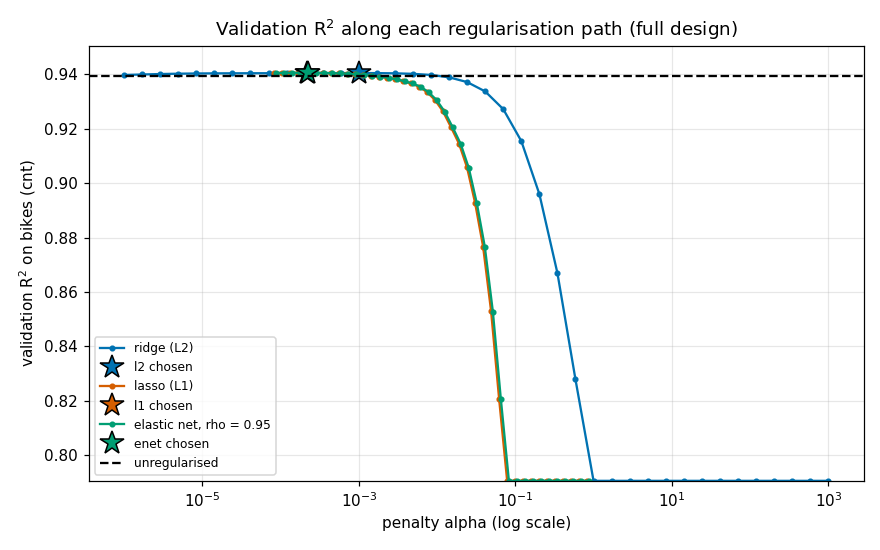

In [50]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_validation_curves(p4))

In [51]:
# Chosen hyper-parameters (best validation R2 on each path; ties go to the larger alpha).
chosen = pd.DataFrame([{"method": m, "lambda": v["lambda"], "l1_ratio": v["l1_ratio"], "val_r2": v["val_r2"],
                        "non_zero": v["n_nonzero"], "of": v["n_features"] - 1} for m, v in p4["methods"].items()])
print(chosen.round(5).to_string(index=False))
enet = pd.DataFrame([{"l1_ratio": float(rho), "best_val_r2": max(r["val_r2"] for r in rows),
                      "best_alpha": max(rows, key=lambda r: (r["val_r2"], r["alpha"]))["alpha"]}
                     for rho, rows in p4["curves"]["enet"].items()])
print(enet.round(5).to_string(index=False))

method  lambda  l1_ratio  val_r2  non_zero  of
  enet 0.00023      0.95 0.94063       285 298
    l1 0.00021      1.00 0.94063       285 298
    l2 0.00100      0.00 0.94052       298 298
 l1_ratio  best_val_r2  best_alpha
     0.10      0.94056     0.00106
     0.30      0.94060     0.00057
     0.50      0.94062     0.00043
     0.70      0.94063     0.00031
     0.90      0.94063     0.00024
     0.95      0.94063     0.00023


In [52]:
# Our solvers (src/regularization.py): closed-form Ridge, and one sweep of coordinate descent with soft-thresholding,
# which is the whole of Lasso (l1_ratio = 1) and Elastic Net.
from src.regularization import cd_sweep, enet_cd_gram, ridge_closed_form, soft_threshold

show_source(soft_threshold, ridge_closed_form, cd_sweep, enet_cd_gram)

def soft_threshold(z, t):
    """S(z, t) = sign(z) * max(|z| - t, 0)."""
    return np.sign(z) * max(abs(z) - t, 0.0)

def ridge_closed_form(X, y, alpha):
    """Solve (G + alpha I) w = c with G = Xc'Xc/n, c = Xc'yc/n.  Returns (b, w).

    Equals sklearn Ridge(alpha = n * alpha).
    """
    G, c, x_mean, y_mean = centred_gram(X, y)
    w = np.linalg.solve(G + alpha * np.eye(G.shape[0]), c)
    return intercept(x_mean, y_mean, w), w

def cd_sweep(G, c, w, q, alpha, l1_ratio):
    """One cyclic pass over the coordinates, updating w and q = G w in place.

    w_j <- S(z_j, alpha*rho) / (G_jj + alpha*(1-rho)),  z_j = c_j - q_j + G_jj w_j.
    Returns the largest coordinate change max_j |dw_j|.
    """
    l1 = alpha * l1_ratio
    l2 = alpha * (1.0 - l1_ratio)
    biggest = 0.0
    for j in range(G.shape[0]):
        gjj = G[j, j]
        if gjj == 0.0:                      # constant column: coefficient stays 0
            continue
        z = c[j] - q[j] + gjj * w[j]
        w_new = so

In [53]:
# The chain, asserted: this phase was built on the Phase 3 artifact that is on disk now, and on its target level.
from src.common import sha256_file

assert p4["upstream_sha256"] == sha256_file("artifacts/p3.json"), "Phase 4 was not built from this Phase 3 artifact"
assert p4["design_from"]["level"] == p3["target_complexity"]["level"], "Phase 4 did not use the Phase 3 target level"
assert p4["design_from"]["n_features_before_candidates"] == p3["target_complexity"]["n_features"]
print("Phase 4 consumed Phase 3: diagnosis", repr(p3["diagnosis"]["label"]), "-> target", p3["target_complexity"]["level"],
      "(hash and level asserted)")

Phase 4 consumed Phase 3: diagnosis 'under-fit' -> target C6_weather_detail (hash and level asserted)


### Justification: fair comparison of the three methods

The three methods get the same design matrix, the same training rows, the same validation rows, the same day folds, the same number of grid points and the same selection rule. Elastic Net has a second knob and therefore six times as many candidates, which gives it a small advantage on the validation set; that is one reason we do not compare on validation alone. For each method at its chosen setting we report validation R² with a bootstrap interval, the held-out-day R² and the chronological R², and for each pair of methods a paired bootstrap interval of the difference on the same validation rows. A difference whose interval contains zero is a tie.

In [54]:
# Fair comparison: same design, same rows, same grid density; three validators and the paired intervals.
table = pd.DataFrame([{"method": m, "val_r2": v["val_r2"], "val_lo": v["val_lo"], "val_hi": v["val_hi"],
                       "day_block_r2": v["day_block_r2"], "day_block_se": v["day_block_se"],
                       "chrono_r2": v["chrono_r2"], "non_zero": v["n_nonzero"]} for m, v in p4["methods"].items()])
print(table.round(4).to_string(index=False))
diffs = pd.DataFrame([{"comparison": k, **v} for k, v in p4["comparisons"].items()])
print(diffs.round(5).to_string(index=False))
best = p4["full_design_best"]
print("full design (with candidate columns): best on validation:", best["method"], round(best["val_r2"], 5))

method  val_r2  val_lo  val_hi  day_block_r2  day_block_se  chrono_r2  non_zero
  enet  0.9406  0.9323  0.9483        0.9452        0.0035     0.9293       285
    l1  0.9406  0.9323  0.9483        0.9452        0.0035     0.9293       285
    l2  0.9405  0.9323  0.9481        0.9450        0.0035     0.9289       298
              comparison    delta      hi       lo
           enet_minus_l1 -0.00000 0.00000 -0.00000
           enet_minus_l2  0.00011 0.00031 -0.00011
enet_minus_unregularised  0.00137 0.00236  0.00039
             l1_minus_l2  0.00011 0.00031 -0.00011
  l1_minus_unregularised  0.00137 0.00237  0.00039
  l2_minus_unregularised  0.00127 0.00222  0.00029
full design (with candidate columns): best on validation: l1 0.94063


### Justification: choice of lambda per method

For each method we take the penalty with the highest validation R² on bikes (ties go to the larger penalty), because the task says tuning uses the validation set and R² on bikes is the metric we are scored on. Two checks sit beside it in the table below: the penalty that is best on held-out days inside the training portion, and the "one standard error" penalty, the largest one whose held-out-day score is within one standard error of that best. If the validation choice were an accident of this particular split, these would disagree strongly with it. Because we select on the validation rows, the validation scores of this phase are slightly optimistic; the held-out-day and chronological columns are not affected by that.

In [55]:
# Two ways to pick the penalty: best validation R2 versus day-block CV (best and one-standard-error rule).
picks = pd.DataFrame([{"method": m, "validation_best": p4["methods"][m]["lambda"], "cv_best": c["cv_best_alpha"],
                       "cv_1se": c["cv_1se_alpha"], "val_r2_at_cv_best": c["val_r2_at_cv_best"],
                       "val_r2_at_cv_1se": c["val_r2_at_cv_1se"], "val_r2_at_validation_best": p4["methods"][m]["val_r2"]}
                      for m, c in p4["cv"].items()])
print(picks.round(5).to_string(index=False))

method  validation_best  cv_best  cv_1se  val_r2_at_cv_best  val_r2_at_cv_1se  val_r2_at_validation_best
  enet          0.00023  0.00046 0.00487            0.94049           0.93670                    0.94063
    l1          0.00021  0.00044 0.00463            0.94049           0.93674                    0.94063
    l2          0.00100  0.00000 0.02424            0.94029           0.93720                    0.94052


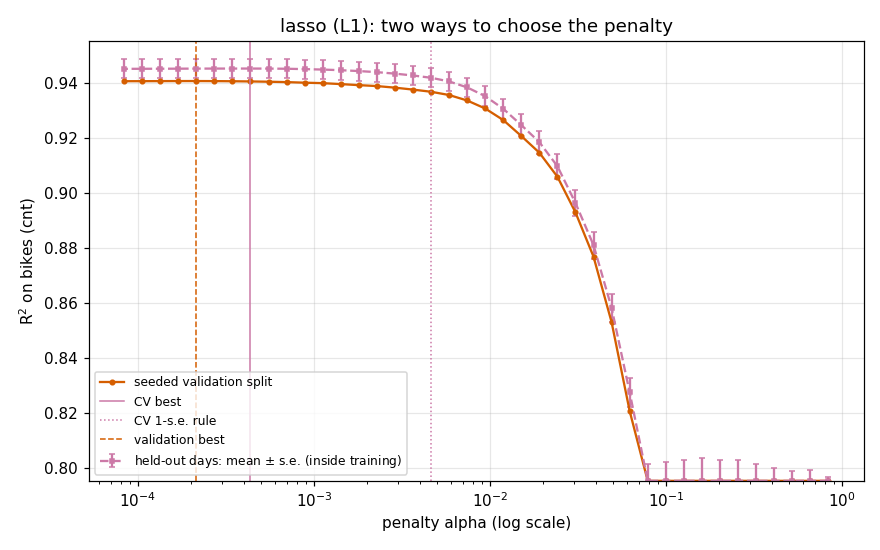

In [56]:
show(plot_cv_vs_validation(p4, "l1"))

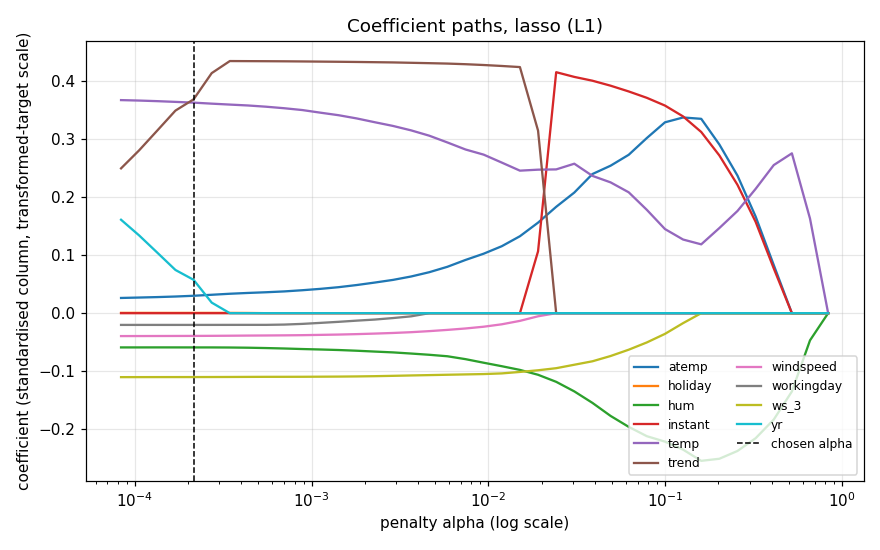

In [57]:
show(plot_paths(p4, "l1"))

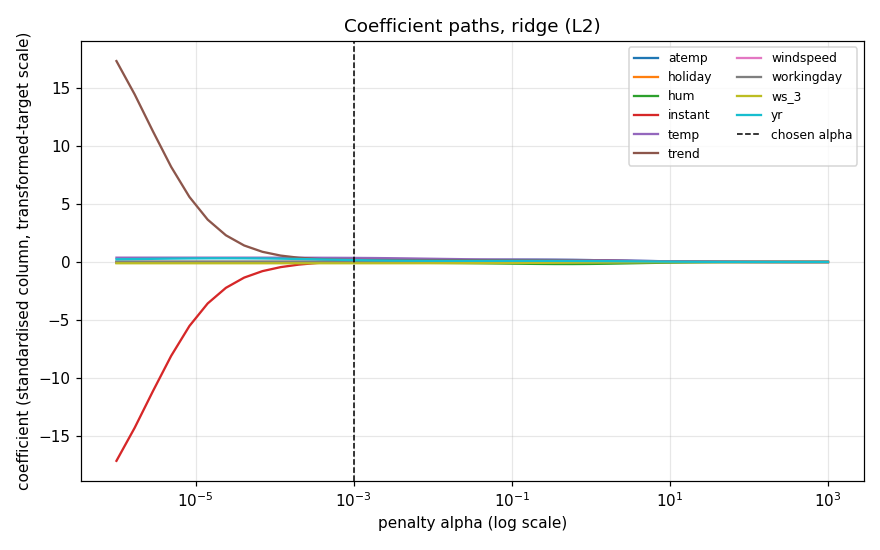

In [58]:
show(plot_paths(p4, "l2"))

In [59]:
# Where does each correlated pair enter the lasso path? (largest alpha with a non-zero weight; None = never)
for name in ("temp", "atemp", "yr", "instant", "trend", "workingday", "holiday"):
    print(f"{name:12s} enters at alpha = {p4['entry_alpha'][name]}")

temp         enters at alpha = 0.6594635761996401
atemp        enters at alpha = 0.4112089970695606
yr           enters at alpha = 0.0002720040864955512
instant      enters at alpha = 0.4112089970695606
trend        enters at alpha = 0.019086630890791826
workingday   enters at alpha = 0.0036541010826229695
holiday      enters at alpha = 0.0005524178922219111


### Justification: the verdict rule

We fixed the rule before running the phase. The reference model is Ridge at its chosen penalty on the full design; "dropping" a column means removing every feature built from it (for `hr` that includes all its interactions) and refitting.

- **Useful:** dropping the column alone lowers validation R² by at least 0.001, with a paired bootstrap interval that stays above zero.
- **Redundant:** dropping it alone costs nothing, but either dropping it together with its partner columns hurts, or the column on its own explains at least 0.01 of the variance. Its information is real but another column already carries it. Partners are the groups we measured to be copies of each other: {`temp`, `atemp`}, {`season`, `mnth`, `dteday`}, {`yr`, `instant`, `dteday`}, {`weekday`, `workingday`, `holiday`}.
- **Uninformative:** neither.
- **One representative per group.** If a group matters as a whole but no single member is missed when dropped, we keep the member that explains most on its own and call it useful; the others are redundant "carried by" it.

Lasso evidence is reported next to the drop tests (how many of the column's own features Lasso keeps, how often over 50 resamples of training days, and where it enters the path), but a Lasso zero alone does not decide a verdict: with copies in the design, which copy Lasso keeps is partly arbitrary.

In [60]:
# Verdict for every original column (cost = validation R2 lost when removed; interval = paired bootstrap).
rows = []
for col, v in p4["column_verdicts"].items():
    n = v["numbers"]
    rows.append({"column": col, "verdict": v["verdict"],
                 "alone": f"{n['drop_alone']['delta']:+.4f} [{n['drop_alone']['lo']:+.4f}, {n['drop_alone']['hi']:+.4f}]",
                 "with_partners": None if n["drop_group"] is None else round(n["drop_group"]["delta"], 4),
                 "solo_r2": None if n["solo_r2"] is None else round(n["solo_r2"], 4),
                 "lasso_kept": f"{n['lasso']['n_own_nonzero']}/{n['lasso']['n_own']}",
                 "max_freq": None if n["lasso"]["max_freq_own"] is None else round(n["lasso"]["max_freq_own"], 2),
                 "carried_by": ", ".join(v["carried_by"]), "representative": v["representative"]})
print(pd.DataFrame(rows).to_string(index=False))

    column   verdict                      alone  with_partners  solo_r2 lasso_kept  max_freq          carried_by  representative
     atemp redundant +0.0000 [-0.0001, +0.0002]         0.0229   0.1141        1/1      0.92                temp           False
    dteday    useful +0.0002 [-0.0004, +0.0008]         0.1203   0.1247        3/5      1.00                                True
   holiday redundant +0.0000 [-0.0000, +0.0000]         0.1851   0.0000        1/1      0.78 weekday, workingday           False
        hr    useful +0.6594 [+0.6112, +0.7079]            NaN   0.4913      23/23      1.00                               False
       hum    useful +0.0055 [+0.0024, +0.0083]            NaN   0.1041        3/3      1.00                               False
   instant redundant +0.0000 [-0.0000, +0.0000]         0.1029   0.0878        0/1      0.00              dteday           False
      mnth redundant -0.0008 [-0.0015, -0.0001]         0.0039   0.0614       9/11      0.94     

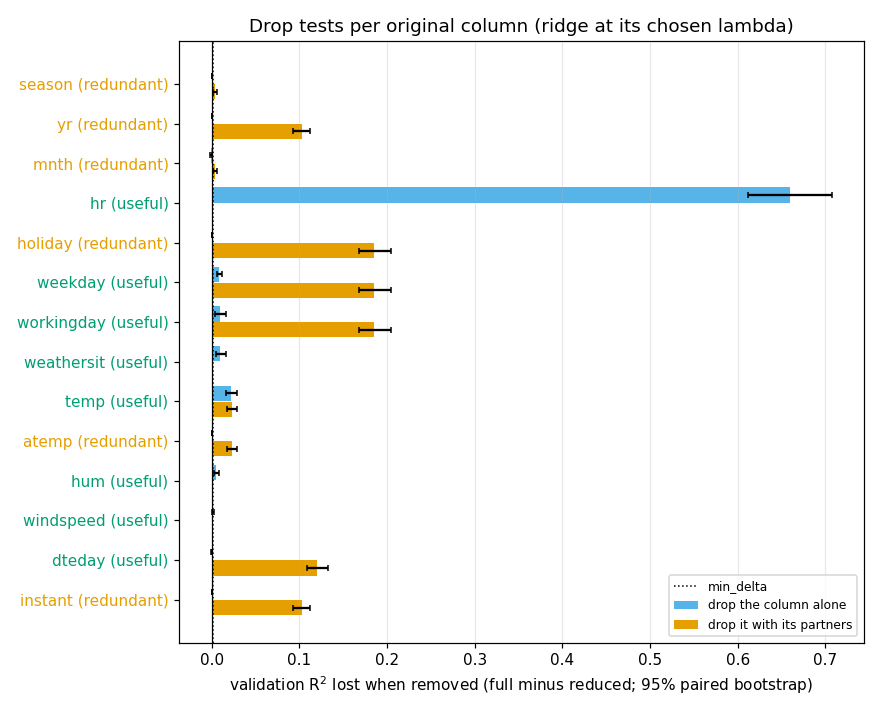

In [61]:
show(plot_verdicts(p4))

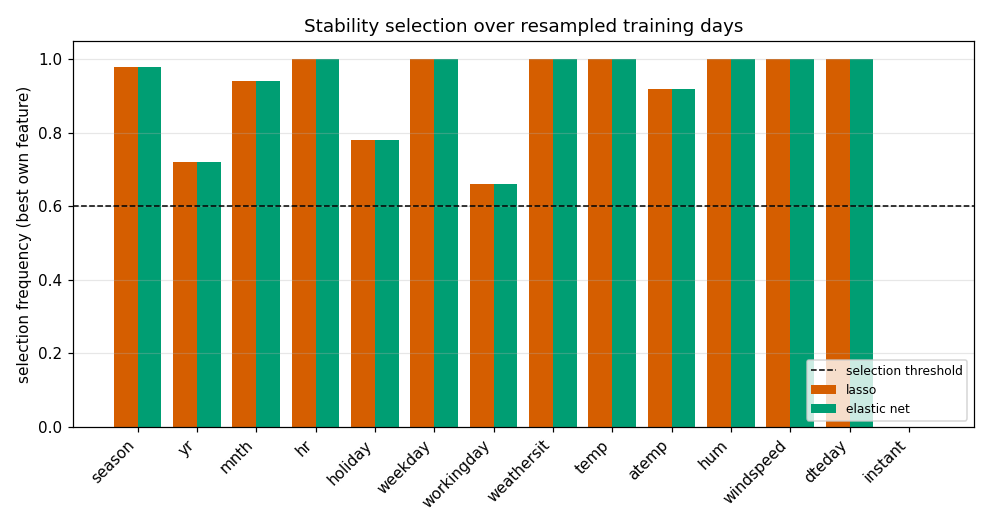

In [62]:
show(plot_stability(p4))

### Justification: the survivor rule

The feature subset handed to Phase 5 is what L1 leaves non-zero, made reproducible. The order matters. We first remove every feature built from a column that is not "useful"; there are 280 features left. On that reduced design we run Lasso again (penalty chosen by validation R²: 8.4e-05), and a feature survives if its weight is non-zero (277 features) and it is selected in at least 0.6 of 50 Lasso fits on resampled training days (277 remain). To be plain about what this means: on this reduced design Lasso removes almost nothing, so the surviving subset is decided almost entirely by the column verdicts, and those verdicts were decided by drop tests scored on the validation set. The subset is a tuning decision made on validation rows, like the degree and the penalties; no feature statistic was fitted on them.

Our first version did it the other way round: take the Lasso zeros from the full design, then remove the copies. That turned out to be wrong for a reason worth stating. With month dummies, `yr` and `instant` in the design, Lasso let them stand in for some of the trend and day-of-year terms and zeroed those; the verdict step then removed the stand-ins as redundant, and the survivors had lost part of the time description twice. Validation R² hardly noticed, but the chronological score fell by about 0.013. Lasso should choose among features only after its choices are no longer between copies.

In [63]:
# Survivors: Lasso on the design of useful columns only; non-zero at its chosen lambda and stable over resampled days.
sel = p4["selection"]
print("counts (useful design -> lasso non-zero -> stable):", p4["survivor_counts"])
print("selection lasso: lambda =", round(sel["lambda"], 6), "| val R2 =", round(sel["val_r2"], 4),
      "| non-zero:", sel["n_nonzero"], "of", sel["n_columns"], "| sweeps exhausted:", sel["not_converged"]["count"])
print("original columns kept:", p4["survivors_original"])
print("survivor columns (expanded features):", len(p4["survivors_expanded"]))

counts (useful design -> lasso non-zero -> stable): {'lasso_nonzero': 277, 'stable': 277, 'useful_design': 280}
selection lasso: lambda = 8.4e-05 | val R2 = 0.9413 | non-zero: 277 of 280 | sweeps exhausted: 0
original columns kept: ['hr', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'dteday']
survivor columns (expanded features): 277


### Justification: final model on the surviving columns

Stage A above answers "which columns matter" and needs every column in the design. It is not the model we want to ship: the columns judged redundant add nothing (dropping `mnth` alone changes validation R² by -0.0008, interval -0.0015 to -0.0001; a negative number means the model is better without it), and several of them are extra descriptions of time, which is exactly where our chronological split shows the model to be fragile. So we repeat the same search for the three methods on the surviving columns only (stage B) and recommend among those. The rule for choosing among the three methods was fixed before the first Phase 4 run: among the methods whose validation difference to the best is within the paired bootstrap noise, take the one with the best held-out-day R². What we added after seeing the first run is this second stage itself, that is, applying the rule to models fitted on the survivors; the earlier runs are in the git history.

In [64]:
# Stage B: the same search (ridge, lasso, elastic net) on the surviving columns only.
final = p4["final"]
print("columns:", final["n_columns"], "| solutions that used all sweeps:", p4["not_converged_final"])
table = pd.DataFrame([{"method": m, "lambda": v["lambda"], "l1_ratio": v["l1_ratio"], "val_r2": v["val_r2"],
                       "day_block_r2": v["day_block_r2"], "day_block_se": v["day_block_se"],
                       "chrono_r2": v["chrono_r2"], "non_zero": v["n_nonzero"]} for m, v in final["methods"].items()])
print(table.round(5).to_string(index=False))
print("unregularised on the survivors:", {k: round(v, 5) for k, v in final["unregularised"].items()})
diffs = pd.DataFrame([{"comparison": k, **v} for k, v in final["comparisons"].items()])
print(diffs.round(5).to_string(index=False))
rec = p4["recommended"]
print("within noise of the best:", rec["candidates"], "| recommended:", rec["method"], "| fitted on:", rec["fitted_on"],
      "| lambda:", rec["lambda"], "| l1_ratio:", rec["l1_ratio"])
print("recommended: val R2", round(rec["val_r2"], 5), "| day-block", round(rec["day_block_r2"], 5),
      "| chrono", round(rec["chrono_r2"], 5))

columns: 277 | solutions that used all sweeps: {'count': 0, 'where': {}}
method  lambda  l1_ratio  val_r2  day_block_r2  day_block_se  chrono_r2  non_zero
  enet 0.00018      0.95 0.94127       0.94630       0.00345    0.93770       270
    l1 0.00017      1.00 0.94127       0.94630       0.00345    0.93771       270
    l2 0.00000      0.00 0.94125       0.94623       0.00345    0.93771       277
unregularised on the survivors: {'alpha': 0.0, 'chrono_r2': 0.93771, 'day_block_r2': 0.94623, 'train_r2': 0.9506, 'train_rmse': 40.08206, 'val_r2': 0.94125, 'val_rmse': 44.67313}
                 comparison    delta      hi       lo
best_minus_full_design_best  0.00064 0.00162 -0.00029
              enet_minus_l1 -0.00000 0.00000 -0.00000
              enet_minus_l2  0.00002 0.00025 -0.00022
   enet_minus_unregularised  0.00002 0.00025 -0.00022
                l1_minus_l2  0.00002 0.00025 -0.00022
     l1_minus_unregularised  0.00002 0.00025 -0.00022
     l2_minus_unregularised -0.00000 0.000

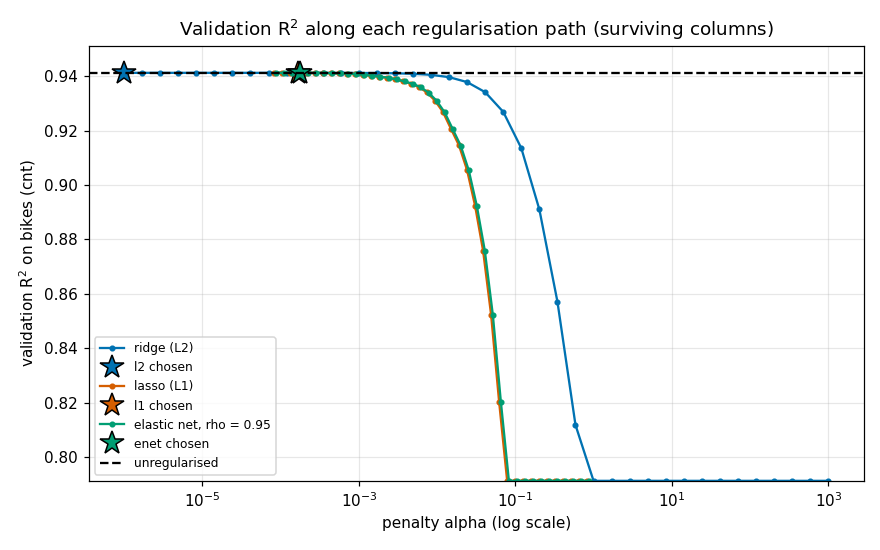

In [65]:
show(plot_validation_curves(p4, stage="final"))

In [66]:
# Does a penalty rescue the over-fit top of the ladder? (informational)
rich = p4["rich_check"]
print(f"level {rich['level']} | weights (with bias): {rich['n_features']} | unregularised val R2: "
      f"{rich['unregularised_val_r2']:.4f}")
for m in ("l2", "l1"):
    print(m, {k: round(v, 5) if isinstance(v, float) else v for k, v in rich[m].items()})
print("best penalised top level minus the recommended (surviving-column) model:",
      {k: round(v, 5) for k, v in rich["paired_best_vs_recommended"].items()})

level C10_month_x_wd_x_hr | weights (with bias): 918 | unregularised val R2: 0.9384
l2 {'day_block_r2': 0.94346, 'lambda': 0.0017, 'val_r2': 0.9386}
l1 {'day_block_r2': 0.94477, 'lambda': 0.00228, 'n_nonzero': 587, 'val_r2': 0.93944}
best penalised top level minus the recommended (surviving-column) model: {'delta': -0.00183, 'hi': 0.00109, 'lo': -0.0046}


## Outcome — Phase 4

**What happened.**
- **The three methods are tied with each other, and the penalty buys very little.** On the full design: Ridge 0.9405, Lasso 0.9406, Elastic Net 0.9406 validation R², against 0.9393 without a penalty. Every paired interval between methods contains zero. The gain over no penalty is 0.0014 (interval 0.0004 to 0.0024): measurable on this design, which carries the duplicated columns, and small. The chosen penalties are tiny (Ridge 1.0e-03, Lasso 2.1e-04); Elastic Net chose l1_ratio 0.95, which makes it almost the same model as Lasso.
- **On the surviving columns the penalty buys nothing.** In stage B Ridge's best penalty is the smallest value on our grid (1e-06), which is our grid's way of saying "none": the unpenalised fit scores 0.9413 and the three methods 0.9413, 0.9413 and 0.9413. Once the copies are gone there is nothing left for regularization to fix, exactly what an "under-fit" diagnosis implies.
- **Where there is variance, the penalty works.** On the over-fit top ladder level Lasso raises validation R² from 0.9384 to 0.9394 while keeping 587 of 918 weights. That is still not better than our recommended model (difference -0.0018, interval -0.0046 to 0.0011).
- **Lasso is not sparse:** it keeps 285 weights. The signal is spread over many hour-specific columns.
- **Verdicts** (table above). Useful: `hr` (dropping it costs 0.659), `temp` (0.0218), `workingday` (0.0092), `weathersit` (0.0100), `weekday` (0.0088), `hum` (0.0055), `windspeed` (0.0014), and `dteday` as the kept representative of time. Redundant: `atemp` (dropping it costs 0.0000, dropping it together with `temp` costs 0.0229), `yr` and `instant` (together with the date terms 0.1029, alone nothing), `season` and `mnth`, and `holiday` (fully determined by `weekday` and `workingday`). No column came out uninformative.
- **Survivors:** 277 features from the eight useful original columns.
- **Final model (stage B):** recommended l1 with λ = 1.7e-04: validation R² 0.9413, RMSE 44.7 bikes, held-out days 0.9463, chronological 0.938. Our first pass, with the log target, ended at 0.9390, 45.5 bikes, 0.9428 and 0.914.

**What surprised us.**
- **Lasso's choices between copies were as arbitrary as we feared, and in one case backwards.** It keeps `atemp` in 0.92 of the resampled fits although dropping `atemp` costs nothing, and it never keeps `instant` (frequency 0.00) although `instant` alone explains 0.088 of the variance. "Lasso set it to zero" was evidence for us, but it would have misled us without the drop tests.
- **`dteday` is useful only as a group.** Dropping the trend and day-of-year terms alone costs 0.0002, because `yr`, `instant`, `season` and `mnth` then step in; dropping them all costs 0.120. We had predicted the copies would be redundant; we had not expected them to be able to replace the original so completely.
- **`mnth` is slightly harmful.** Removing it improves validation R² (see above). Month dummies add steps to a season that the smooth day-of-year terms already describe.
- **`windspeed` is useful, but only as we represent it now.** In our very first Phase 4 run, with wind as a single linear column, the same rule called it uninformative; with the square and the interaction with temperature that Phase 3 added, dropping it costs 0.0014 with an interval that just clears zero. We predicted it might flip back in the second pass; it did not. A verdict about a column is a verdict about the column *as we represented it*.
- **Our own survivor rule was wrong at first** (see the justification above): taking Lasso zeros before removing the copies quietly cost robustness on later months.
- **Second pass:** every verdict is the same as with the log target, and the three methods are tied again, as we expected. The recommended method changed from Elastic Net to l1; with the methods tied within noise that is the tie-break on held-out days, not a finding.
- Some Lasso fits at one large penalty value on the full design ran out of sweeps (7 fits; none is a chosen model). The exactly duplicated columns are the cause; on the survivors every fit converged.

**Handed to Phase 5:** the surviving feature list. Handed to the submission: the stage-B recommended model.

## Expectation — Phase 5: Logistic Regression

*Written before running the phase (see the git history of this file).*

**What we do.** We turn `cnt` into a yes/no target, "is this a high-demand hour?", and train our own logistic regression (gradient descent on the log-loss) using only the feature columns that survived Phase 4, loaded from `artifacts/p4.json`.

**The flaw of a single global threshold, as we see it.** If "high" means "more than the 75th percentile of all hours", then high demand is simply 8 am and 5–6 pm on working days and midday at weekends. A classifier for that label only has to read the clock; it tells the operator nothing they do not already know from the timetable. A threshold per (working day, hour) fixes the clock problem but creates a calendar one: demand grew about 65% from 2011 to 2012, so nearly every "high" hour would be a 2012 hour.

**Our label.** An hour is high-demand when its `cnt` is above the 75th percentile of training hours with the same year, day type and hour of day. The 96 thresholds are computed on the training portion only and looked up for validation rows. "High" then means "busier than three quarters of comparable hours", which is the case where the usual allocation of bikes is not enough.

**What we expect, and why.**

1. *Class balance.* About 25% positives in training and validation, and about the same in each year. The majority-class accuracy is therefore about 0.75, so accuracy alone will flatter any model; we will read F1, precision, recall, ROC-AUC and PR-AUC together.
2. *The foils.* Under the global threshold, hour dummies alone should reach an AUC near 0.85 and the full model near 0.98: impressive and useless. Under the (working day, hour) rule without year, the trend alone should reach about 0.8. Under our rule, hour alone should sit at chance (0.50) and trend alone close to it.
3. *Our classifier.* With the easy cues removed, the model has to rely on weather and season. We expect ROC-AUC between 0.82 and 0.88, well below the foil's number, and we will treat that lower figure as the honest one. Accuracy at a 0.5 cut-off should be only a few points above 0.75.
4. *Operating threshold.* Missing a high-demand hour (empty docks) is worse than a false alarm (a few idle bikes). With the same 3:1 cost ratio as the Phase 1 bonus, the cost-minimising cut-off for a calibrated model is 1/(1+3) = 0.25, not 0.5. We expect recall to rise sharply and precision to fall at 0.25, and the validation cost curve to have its minimum near 0.25 if our probabilities are well calibrated.
5. *Features.* Hour dummies should matter little on their own here, because the label is already relative to the hour; temperature, humidity, weather situation and the day-of-year terms should carry the model.

## Expectation — Phase 5, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged.*

The label and the classifier do not use the regression target, so Phase 5 changes only if the surviving feature list
changes. We expect the same class balance and a ROC-AUC within 0.005 of the first pass (0.886). A tree model that we
tried outside the pipeline reaches about 0.90 on the same label, so we do not expect the logistic model to go higher
than that.

### Justification: label rule

- **The flaw of one global threshold.** If "high" means "above the 75th percentile of all hours", the label is the timetable: 8h and 17–18h on working days, midday at weekends. In the table below, hour dummies alone then reach a ROC-AUC of 0.855 and the full model 0.985. That looks excellent and tells the operator nothing new.
- **Fixing the clock creates a calendar problem.** With one threshold per (day type, hour), hour alone drops to 0.533, but because demand grew so much, only 0.054 of 2011 validation hours are "high" against 0.421 of 2012 hours, and the trend alone reaches 0.810. Now the label is the year.
- **Our rule.** An hour is high-demand when `cnt` is above the 0.75 quantile of training hours with the same year, day type and hour: 96 thresholds, each from at least 50 training hours, looked up for validation rows. Hour alone is at chance (0.501), trend alone nearly so (0.577), and the positive share is the same in both years (0.239 and 0.262).
- **Why this is meaningful for the operator.** The operator already plans for rush hours and for growth. What they cannot read off a timetable is whether *this* 8 am will be busier than a normal 8 am this year. The top quarter of comparable hours is where a normal allocation of bikes runs short.
- **Why the 75th percentile.** It keeps enough positives to learn from (about a quarter) while still meaning "clearly above normal"; a 90th percentile would leave about five positives in the smallest cells.
- **Limit.** A new year has no cell of its own; in use, the thresholds would have to be rolled forward, for example last year's cell scaled by the fitted trend.

In [67]:
# Phase 5 loads artifacts/p4.json for the surviving columns, builds the label with thresholds fitted on the training
# rows, and fits our own logistic regression. A full run takes about three minutes (the l2 sweep and the label-rule
# foils), so the cell loads the stored artifact when config and upstream are unchanged.
import pandas as pd

from src.common import cached_or_run, load_config, read_artifact
from src.phases import p5 as p5mod
from src.plots_p5 import plot_calibration, plot_label_variants, plot_roc_pr, plot_threshold_curve

p5 = phase("p5", p5mod.run, upstream="p4")  # writes artifacts/p5.json when it has to run

loaded cached artifacts/p5.json (same config and upstream artifact); run `python run.py p5` or change CFG to recompute


In [68]:
# The chain: every feature of this phase must be a survivor of Phase 4.
p4 = read_artifact("p4")
survivors = set(p4["survivors_expanded"])
assert set(p5["features"]) <= survivors, "Phase 5 uses a column that Phase 4 dropped"
print("Phase 4 surviving columns :", len(survivors), "from original columns", p4["survivors_original"])
print("Phase 5 features (no bias):", len(p5["features"]), "| all in the Phase 4 survivors: True")
print("columns incl. bias        :", p5["n_features"], "| training rows:", p5["n_train"], "| validation rows:", p5["n_val"])

Phase 4 surviving columns : 277 from original columns ['hr', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'dteday']
Phase 5 features (no bias): 277 | all in the Phase 4 survivors: True
columns incl. bias        : 278 | training rows: 8708 | validation rows: 2178


In [69]:
# The label: high demand = cnt above the quantile of training hours with the same year, day type and hour.
rule = p5["threshold_rule"]
print("quantile:", rule["quantile"], "| cells:", rule["group_by"], "| fitted on:", rule["fitted_on"])
print("number of cells:", rule["n_cells"], "| fewest training hours in a cell:", rule["min_cell_n"])
thresholds = pd.DataFrame(rule["table"])
peaks = thresholds[thresholds["hr"].isin([3, 8, 12, 17])].pivot_table(index=["yr", "workingday"], columns="hr",
                                                                      values="threshold")
print("\nthreshold (bikes) for four hours of the day:")
print(peaks.round(1).to_string())
balance = p5["class_balance"]
print(pd.Series({"positives, train": balance["train"], "positives, validation": balance["val"],
                 "positives, validation 2011": balance["val_by_year"]["0"],
                 "positives, validation 2012": balance["val_by_year"]["1"],
                 "majority-class accuracy": balance["majority_accuracy"]}).round(4).to_string())

quantile: 0.75 | cells: ['yr', 'workingday', 'hr'] | fitted on: train
number of cells: 96 | fewest training hours in a cell: 50

threshold (bikes) for four hours of the day:
hr               3      8      12     17
yr workingday                           
0  0           30.0  101.0  375.5  364.5
   1            6.0  438.0  195.0  552.0
1  0           40.0  170.0  543.0  555.0
   1            6.0  692.0  305.5  812.0
positives, train              0.2455
positives, validation         0.2502
positives, validation 2011    0.2386
positives, validation 2012    0.2615
majority-class accuracy       0.7498


In [70]:
# The foils: the same three models under three label rules. Only the last rule keeps the hour and the trend at chance.
foils = pd.DataFrame(p5["label_variants"])
foils["rule"] = foils["group_by"].map(lambda g: " + ".join(g) or "global")
print(foils[["rule", "pos_train", "pos_val", "pos_val_2011", "pos_val_2012", "auc_hour_only", "auc_trend_only",
             "auc_full", "acc_full_at_0_5", "majority_accuracy"]].round(3).to_string(index=False))
print("foil fits that did not converge:", p5["foil_not_converged"])

                rule  pos_train  pos_val  pos_val_2011  pos_val_2012  auc_hour_only  auc_trend_only  auc_full  acc_full_at_0_5  majority_accuracy
              global      0.250    0.239         0.154         0.321          0.855           0.662     0.985            0.949              0.761
     workingday + hr      0.245    0.240         0.054         0.421          0.533           0.810     0.937            0.894              0.760
yr + workingday + hr      0.246    0.250         0.239         0.262          0.501           0.577     0.885            0.827              0.750


foil fits that did not converge: []


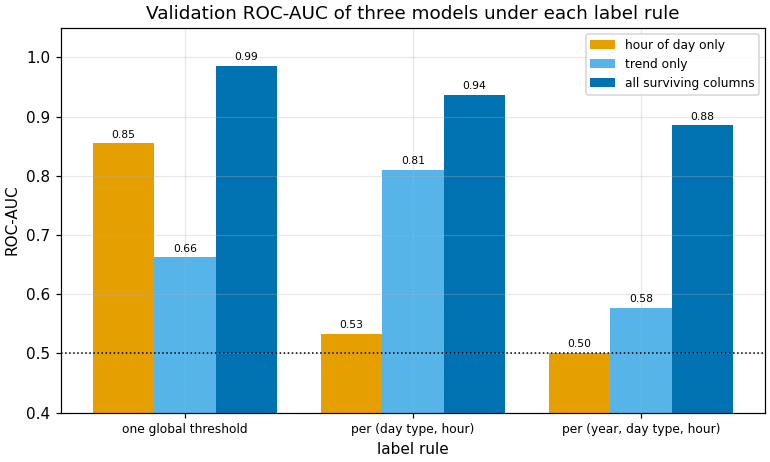

In [71]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_label_variants(p5))

### Justification: regularisation of the classifier

The classifier is our own logistic regression: gradient descent on the mean log-loss, with the step 1/(λ_max/4 + l2), which is the safe step for this loss because its curvature is at most a quarter of that of the squared loss. It uses only the Phase 4 survivors (the assert above). We add a small ridge term because, without any penalty, some weights of rarely active columns keep growing and gradient descent does not settle (the l2 = 0 row below stops at the iteration cap). The strength is chosen by validation ROC-AUC among 0.0, 0.0001, 0.001 and 0.01; ties within 0.0001 go to the larger value. Chosen: 0.001.

In [72]:
# Ridge strength by validation ROC-AUC (ties within 1e-4 go to the larger l2); the cost of each fit is its iterations.
sweep = pd.DataFrame(p5["l2_sweep"])
print(sweep.round(5).to_string(index=False))
print("\nchosen l2:", p5["l2"], "| iterations:", p5["iterations"], "| stop:", p5["stop_reason"],
      "| learning rate:", round(p5["lr"], 4))
print("gradient check (max relative error): at zeros", f"{p5['gradient_check_at_zeros']:.1e}",
      "| halfway to the final weights", f"{p5['gradient_check_at_half']:.1e}")

 iterations     l2 stop_reason  train_logloss  val_logloss  val_roc_auc
      50000 0.0000    max_iter        0.30794      0.36894      0.88329
      11105 0.0001   converged        0.30802      0.36326      0.88452
       2954 0.0010   converged        0.30965      0.35833      0.88495
        574 0.0100   converged        0.32726      0.36325      0.88013

chosen l2: 0.001 | iterations: 2954 | stop: converged | learning rate: 1.159
gradient check (max relative error): at zeros 4.9e-08 | halfway to the final weights 7.1e-08


In [73]:
# Our logistic regression (src/logistic.py): the log-loss, its gradient, and the fit, which reuses the Phase 1
# gradient-descent loop.
from src.logistic import fit_logistic, logloss, logloss_grad, sigmoid

show_source(sigmoid, logloss, logloss_grad, fit_logistic)

def sigmoid(eta):
    """Numerically stable 1/(1+exp(-eta)): never exponentiates a positive number."""
    eta = np.asarray(eta, dtype=np.float64)
    e = np.exp(-np.abs(eta))
    return np.where(eta >= 0, 1.0 / (1.0 + e), e / (1.0 + e))

def logloss(X, y, w, l2=0.0):
    """Mean cross-entropy via -log p = logaddexp(0, -eta), -log(1-p) = logaddexp(0, eta)."""
    eta = X @ w
    data_term = np.mean(y * np.logaddexp(0.0, -eta) + (1.0 - y) * np.logaddexp(0.0, eta))
    return float(data_term + 0.5 * l2 * np.sum(w[1:] ** 2))

def logloss_grad(X, y, w, l2=0.0):
    """(1/n) X'(p - y) + l2 * w with the bias entry of the penalty set to 0."""
    grad = X.T @ (sigmoid(X @ w) - y) / X.shape[0]
    grad[1:] += l2 * w[1:]
    return grad

def fit_logistic(X, y, l2=0.0, lr=None, tol_loss=1e-10, tol_grad=1e-6, max_iter=50000):
    """Gradient descent from w = 0.  Default lr = 1/(lambda_max(X'X/n)/4 + l2).

    The Hessian is at most (1/4) X'X/n + l2 I, so this step is 1/L for the smoothness L.
   

### Justification: metrics

About one hour in four is positive, so a model that always answers "normal" has an accuracy of 0.750. Accuracy alone would flatter us, so we read it together with: **recall** (how many high-demand hours we catch, the operator's main concern), **precision** (how many alarms are real), **F1** (their balance), **ROC-AUC** (ranking quality, independent of the cut-off and of the class balance) and **PR-AUC** (ranking quality on the positive class, more demanding when positives are the minority). The task's three required numbers, accuracy, F1 and ROC-AUC, are reported at our operating cut-off; the others are shown beside them.

In [74]:
# Metrics on the validation rows at the cost threshold 1/(1+c), at 0.5 and at the F1-optimal grid threshold.
columns = ["threshold", "accuracy", "f1", "precision", "recall", "roc_auc", "pr_auc", "cost"]
table = pd.DataFrame({"at 1/(1+c)": p5["metrics"], "at 0.5": p5["metrics_at_0_5"],
                      "at F1-optimal": p5["metrics_at_f1_opt"]}).T[columns]
print(table.round(4).to_string())
print("\nmajority-class accuracy:", round(p5["class_balance"]["majority_accuracy"], 4))
print("validation ROC-AUC 95% interval:", round(p5["val_auc_bootstrap"]["lo"], 4), "to",
      round(p5["val_auc_bootstrap"]["hi"], 4))
print("training rows at 1/(1+c):", {k: round(v, 4) for k, v in p5["train_metrics"].items()})
conf = p5["metrics"]["confusion"]
print("\nconfusion matrix at 1/(1+c) (rows = truth):")
print(pd.DataFrame([[conf["tn"], conf["fp"]], [conf["fn"], conf["tp"]]], index=["truly normal", "truly high"],
                   columns=["predicted normal", "predicted high"]).to_string())

              threshold  accuracy        f1 precision    recall   roc_auc    pr_auc      cost
at 1/(1+c)         0.25  0.784206  0.658926  0.545018  0.833028  0.884954  0.727973  0.299357
at 0.5              0.5  0.826905  0.627838  0.679487  0.583486  0.884954  0.727973  0.381543
at F1-optimal      0.35   0.81405  0.669388  0.602941  0.752294  0.884954  0.727973  0.309917

majority-class accuracy: 0.7498
validation ROC-AUC 95% interval: 0.8694 to 0.8997
training rows at 1/(1+c): {'accuracy': 0.8089, 'f1': 0.6907, 'roc_auc': 0.9146}

confusion matrix at 1/(1+c) (rows = truth):
              predicted normal  predicted high
truly normal              1254             379
truly high                  91             454


### Justification: operating threshold

A missed high-demand hour means empty docks and lost customers; a false alarm means a few idle bikes. We use the same 3:1 cost ratio as in the Phase 1 bonus. For a model whose probabilities are calibrated, raising an alarm is worth it when p × 3 > (1 − p) × 1, that is when p > 1/(1+3) = 0.25. So our cut-off is 0.25, not the habitual 0.5. The plot below checks the argument on the validation rows: the cost is lowest at 0.2 on our grid, and the calibration plot further down shows how far the probabilities can be trusted (largest gap 0.091).

cost ratio (miss : false alarm): 3.0 | 1/(1+c) = 0.25
grid threshold with the lowest validation cost: 0.2 | with the highest F1: 0.35


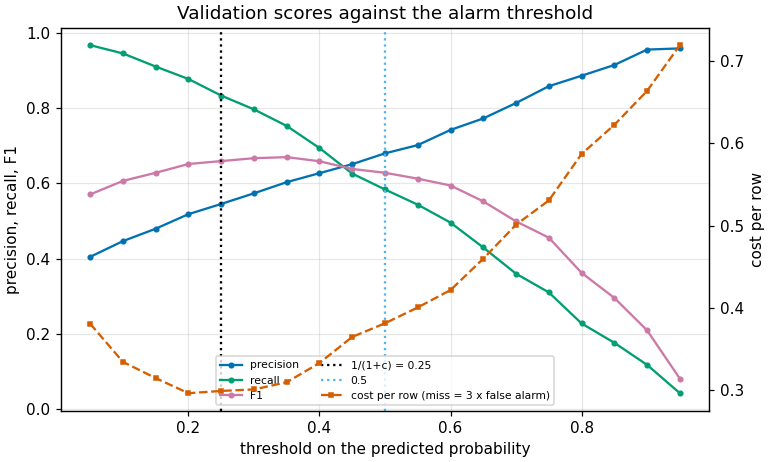

In [75]:
print("cost ratio (miss : false alarm):", p5["cost_ratio"], "| 1/(1+c) =", p5["t_cost"])
print("grid threshold with the lowest validation cost:", p5["t_cost_empirical"],
      "| with the highest F1:", p5["t_f1"])
show(plot_threshold_curve(p5))

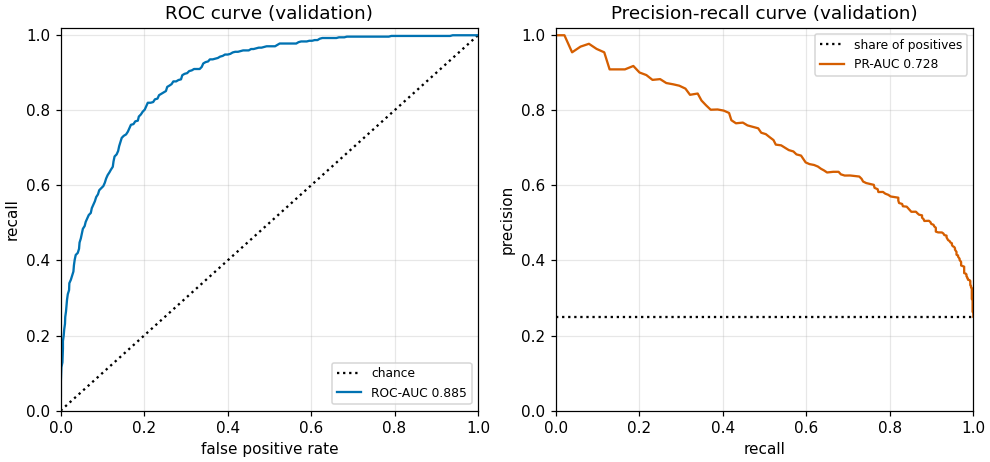

In [76]:
show(plot_roc_pr(p5))

largest gap between predicted and observed share (bins with >= 30 rows): 0.0907


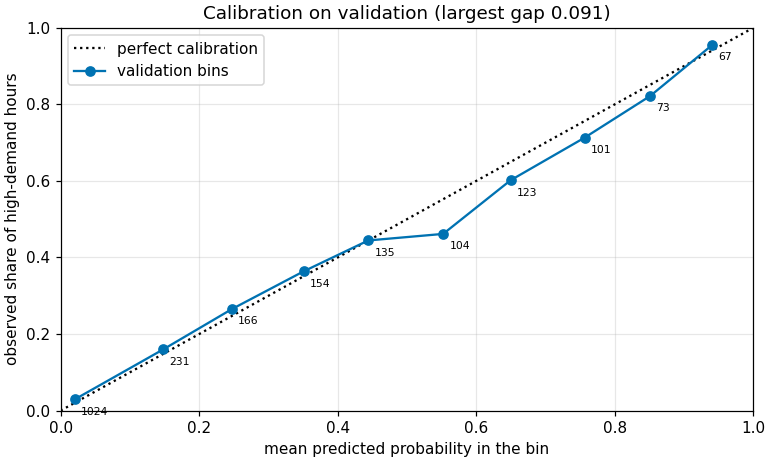

In [77]:
print("largest gap between predicted and observed share (bins with >= 30 rows):", round(p5["calibration_max_gap"], 4))
show(plot_calibration(p5))

In [78]:
# What the classifier relies on: the largest standardised weights, and the share of sum|w| by original column.
print(pd.DataFrame(p5["top_coefficients"]).round(3).to_string(index=False))
print("\nshare of sum|w| by original column:")
print(pd.Series(p5["coef_abs_share_by_column"]).round(3).to_string())

     name  weight
     temp   2.152
   temp^2  -1.004
   doy_s1  -0.872
   temp^3  -0.832
   doy_c1  -0.791
      hum  -0.418
   doy_s2  -0.392
     wk_5   0.376
wk_2*hr_6   0.373
hr_3*temp  -0.361
 wslag1_3  -0.349
hr_9*temp  -0.348
     wk_6   0.344
wk_2*hr_9   0.337
wk_2*hr_7   0.333

share of sum|w| by original column:
dteday        0.052
hr            0.412
hum           0.042
temp          0.161
weathersit    0.028
weekday       0.262
windspeed     0.005
workingday    0.038


### Pipeline retrospective

Each phase used what the previous one produced, and the table below is built from the five artifact files.

- **Phase 1** gave a working optimiser and an honest baseline: validation R² 0.736 with 36 weights. Its residuals showed the missing structure.
- **Phase 2** started from Phase 1's weights (first loss equal to Phase 1's last) and added what those residuals asked for: R² 0.918.
- **Phase 3** showed that this model was still too simple, not too flexible, and that the gap to a chronological split is drift rather than leakage. It moved the target to 282 weights: 0.941 on validation, 0.946 on held-out days, 0.938 chronologically.
- **Phase 4** found, as that diagnosis implies, that penalties change little (all three methods within noise of each other), used them to sort the 14 columns into useful, redundant and uninformative, and recommended l1 on the 277 surviving features: R² 0.941, RMSE 44.7.
- **Phase 5** reused exactly those features for a classifier: ROC-AUC 0.885, F1 0.659, accuracy 0.784 at the cost-based cut-off.

The thread through all five: on this data the errors come from bias. Every gain came from giving the linear model structure the data really has; the classical variance cures (higher degree, stronger penalty) did nothing measurable. **The regression model our pipeline recommends, and the one behind our submission, is the Phase 4 stage-B model.**

In [79]:
retro = pd.DataFrame(p5["retrospective"])
print(retro[["phase", "n_features", "train_score", "val_score", "val_rmse"]].round(4).to_string(index=False))
print()
for _, row in retro.iterrows():
    print(f"{row['phase']}: consumed {row['consumed']}; settings {row['hyperparameters']}" +
          (f"; {row['extra']}" if row["extra"] else ""))

              phase  n_features  train_score  val_score  val_rmse
P1 gradient descent          36       0.7462     0.7361   94.6902
      P2 polynomial          61       0.9206     0.9178   52.8411
   P3 bias-variance         282       0.9506     0.9413   44.6534
  P4 regularization         278          NaN     0.9413   44.6655
        P5 logistic         278       0.9146     0.8850       NaN

P1 gradient descent: consumed 35 base columns + bias, power-family target (exponent 0.1); settings lr=0.506, 496 iterations
P2 polynomial: consumed P1 weights as the starting point; settings degree=3 on temp, blocks=wd_x_hr; gain over P1 = 0.1817 R2
P3 bias-variance: consumed P2 design as anchor of a 11-level ladder; settings target C6_weather_detail (282 weights); target seeded/day-block/chrono = 0.941/0.946/0.938; anchor = 0.918/0.918/0.894
P4 regularization: consumed P3 target design + the held-back candidate columns; settings l2 lambda=0.001 val_r2=0.9405; l1 lambda=0.000215 val_r2=0.9406; en

## Outcome — Phase 5

**What happened.**
- Class balance is as planned: 0.246 positives in training, 0.250 in validation, 0.239 and 0.262 by year.
- The foils behaved as predicted: global threshold, hour-only AUC 0.855 and full model 0.985; our rule, hour-only 0.501.
- Our classifier: ROC-AUC 0.885 (95% interval 0.869–0.900), PR-AUC 0.728. At the cut-off 0.25: accuracy 0.784, F1 0.659, precision 0.545, recall 0.833. At 0.5: accuracy 0.827, F1 0.628, recall 0.583.
- The cost argument holds up: at 0.25 we miss 91 high-demand hours and raise 379 false alarms (cost 0.299 per hour); at 0.5 we would miss 227 (cost 0.382).

**What surprised us.**
- Accuracy is *lower* at our chosen cut-off (0.784) than at 0.5 (0.827), and barely above the do-nothing baseline of 0.750. Judged by accuracy alone our operating point looks like a mistake; judged by the operator's cost it is clearly the better one. This is the clearest case in the project of a metric pointing the wrong way.
- The cost argument holds up in practice: on our grid of cut-offs (steps of 0.05) the validation cost is lowest at 0.2, next to the theoretical 0.25, and the probabilities are usable but not perfectly calibrated (largest gap 0.091). We kept the theoretical cut-off instead of tuning it on the validation rows.
- *Second pass:* as expected the classifier hardly moved (ROC-AUC 0.885 against 0.886), because neither the label nor the features depend on the regression target; only the survivor list changed slightly. The chosen ridge strength changed to 0.001, by a margin inside the noise of the validation AUC.
- The honest task is much harder than the trivial one (AUC 0.885 against 0.985). Whether an hour is unusually busy for its slot depends on things we only partly observe: the weather explains some of it, events and school holidays are not in the data.
- Even with the label made relative to the hour, hour-related columns still carry a large share of the weights (table above): the weather effect differs by hour, so the survivors' hour × weather interactions matter even though the hour alone predicts nothing.

## Phase 6 — Final model and submission

**Which model.** The regression model our pipeline recommends is the Phase 4 stage-B model: l1 with λ = 1.7e-04 and l1_ratio 1.0 on the surviving features. Nothing is tuned here.

**Refit on training + validation, and why.** The hyper-parameters stay exactly as validated, but the weights are refitted on all 10886 labelled rows. The Phase 3 learning curve of the target was still rising at full size (0.940 with 80% of the training days, 0.941 with all of them), so a quarter more rows should help a little, and the validation rows are days of the same months as the hidden ones. The scaler and the humidity fill stay as fitted on the training portion, so the hidden rows go through exactly the transformations used everywhere else. The cell first refits the validated model on the training rows alone and asserts that it reproduces the Phase 4 weights.

**What we check without labels.** We cannot score the hidden days, and we do not tune anything on them. We only check that the predictions are sane: same rows and order as `test.csv`, no missing or negative values, the refitted model agrees closely with the validated one (correlation 0.9997), and the predicted hourly profile by day type looks like the training profile (each cell between 0.81 and 1.15 times the training mean).

**What the model cannot adapt to.** It extrapolates growth as a straight line on the transformed scale, which Phase 3 showed to be somewhat too steep beyond the observed period; it has never seen a zero-demand hour, weather outside the observed range, or holidays other than those in the training days. For the hidden days, which lie inside the two observed years, the held-out-day estimate of Phase 4 (0.946) is our best guess of the score; for a genuinely later period we would expect something nearer the chronological estimate (0.938).

In [80]:
# Phase 6 reads artifacts/p4.json (the recommended regression model on the surviving columns), refits it on training
# plus validation rows and predicts the hidden days. It does not re-run any earlier phase.
import numpy as np
import pandas as pd

from src import predict
from src.common import config_seed, load_config, load_test, load_train, read_artifact, sha256_file
from src.plots_p5 import plot_test_profile

CFG = globals().get("CFG") or load_config()
p6 = predict.run(CFG)  # writes sample_submission.csv and artifacts/p6.json

In [81]:
# What was submitted and how it compares with the model that was validated (model A, training rows only).
summary = {
    "model (Phase 4 recommended)": p6["model"]["method"],
    "lambda": p6["model"]["lambda"],
    "l1_ratio": p6["model"]["l1_ratio"],
    "refit on": p6["refit_on"],
    "rows used to fit": p6["n_fit_rows"],
    "rows predicted": p6["n_test_rows"],
    "model A reproduces the Phase 4 weights (max gap)": p6["model_a_gap_to_p4"],
    "prediction mean": p6["pred"]["mean"],
    "prediction median": p6["pred"]["median"],
    "prediction min": p6["pred"]["min"],
    "prediction max": p6["pred"]["max"],
    "predictions below 1 bike": p6["pred"]["n_below_1"],
    "predictions clipped at 0": p6["pred"]["n_clipped"],
    "mean cnt of the training rows": p6["train_cnt_mean"],
    "A versus B on the hidden rows: correlation": p6["a_vs_b_on_test"]["corr"],
    "A versus B: mean ratio B / A": p6["a_vs_b_on_test"]["mean_ratio"],
    "A versus B: mean absolute difference": p6["a_vs_b_on_test"]["mean_abs_diff"],
    "A versus B: largest absolute difference": p6["a_vs_b_on_test"]["max_abs_diff"],
    "profile ratio min / max (per day type and hour)": f"{p6['profile_ratio']['min']:.3f} / {p6['profile_ratio']['max']:.3f}",
    "cells outside 0.4-2.5": p6["profile_ratio"]["cells_outside_0_4_2_5"],
    "daily-total ratio min / max": f"{p6['daily_total_ratio']['min']:.3f} / {p6['daily_total_ratio']['max']:.3f}",
    "mean prediction 2011 / 2012": f"{p6['by_year_mean']['0']:.1f} / {p6['by_year_mean']['1']:.1f}",
}
print(pd.Series(summary, name="value").to_string())

model (Phase 4 recommended)                                       l1
lambda                                                       0.00017
l1_ratio                                                         1.0
refit on                                            train+validation
rows used to fit                                               10886
rows predicted                                                   574
model A reproduces the Phase 4 weights (max gap)                 0.0
prediction mean                                           199.317927
prediction median                                             161.14
prediction min                                                  0.94
prediction max                                                884.93
predictions below 1 bike                                           1
predictions clipped at 0                                           0
mean cnt of the training rows                             191.607487
A versus B on the hidden rows: cor

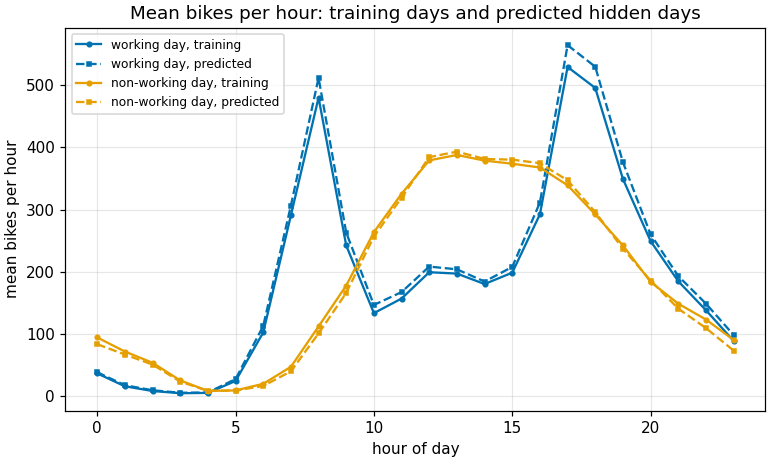

In [82]:
labelled_df, test_df = load_train(CFG), load_test(CFG)
sub = pd.read_csv(predict.SUBMISSION_PATH)
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_test_profile(labelled_df, test_df, sub))

In [83]:
# The same checks as tools/submission_check.py, inline (hard failures are asserts).
assert list(sub.columns) == ["instant", "cnt"], list(sub.columns)
assert len(sub) == len(test_df), (len(sub), len(test_df))
assert (sub["instant"].to_numpy() == test_df["instant"].to_numpy()).all(), "row order differs from the hidden file"
assert np.isfinite(sub["cnt"].to_numpy(dtype=float)).all(), "NaN or inf in cnt"
assert (sub["cnt"] >= 0).all(), "negative predictions"
assert not (sub["cnt"] == 0).all(), "all predictions are 0"
print("submission:", sub.shape, "| columns", list(sub.columns), "| order equals the hidden file | no NaN | no negatives")
print("cells outside the 0.4-2.5 band of the training profile:", p6["profile_ratio"]["cells_outside_0_4_2_5"],
      "| daily totals vs same-month training days:", round(p6["daily_total_ratio"]["min"], 2), "to",
      round(p6["daily_total_ratio"]["max"], 2))

submission: (574, 2) | columns ['instant', 'cnt'] | order equals the hidden file | no NaN | no negatives
cells outside the 0.4-2.5 band of the training profile: 0 | daily totals vs same-month training days: 0.85 to 1.58


In [84]:
# All chain assertions in one table: hash chain p1 -> p6, shared seed, Phase 2 start loss = Phase 1 final loss,
# Phase 5 features among the Phase 4 survivors, model A reproduces Phase 4.
arts = {name: read_artifact(name) for name in ("p1", "p2", "p3", "p4", "p5", "p6")}
checks = []
for prev, name in zip(("p1", "p2", "p3", "p4", "p5"), ("p2", "p3", "p4", "p5", "p6")):
    checks.append((f"{name}.upstream_sha256 == sha256(artifacts/{prev}.json)",
                   arts[name]["upstream_sha256"] == sha256_file(f"artifacts/{prev}.json")))
checks.append(("p1 has no upstream", arts["p1"]["upstream_sha256"] is None))
checks.append(("same seed in p1..p6 and equal to the seed of the config",
               {a["seed"] for a in arts.values()} == {config_seed(CFG)}))
checks.append(("p2 starts from the p1 weights", arts["p2"]["init_weights_source"] == "p1"))
checks.append(("p2.init_loss == p1.train_loss_final (1e-9)",
               abs(arts["p2"]["init_loss"] - arts["p1"]["train_loss_final"]) <= 1e-9 * max(1.0, arts["p1"]["train_loss_final"])))
checks.append(("p5.features are a subset of p4.survivors_expanded",
               set(arts["p5"]["features"]) <= set(arts["p4"]["survivors_expanded"])))
checks.append(("p4.recommended was fitted on the survivors, p6 uses the same columns",
               arts["p4"]["recommended"].get("fitted_on") == "survivors"))
checks.append(("model A reproduces the p4 weights (< 1e-6)", arts["p6"]["model_a_gap_to_p4"] < 1e-6))
checks.append(("p5 chosen model converged", arts["p5"]["stop_reason"] == "converged"))
report = pd.DataFrame(checks, columns=["assertion", "holds"])
print(report.to_string(index=False))
assert report["holds"].all(), "a chain assertion failed"

                                                           assertion  holds
                     p2.upstream_sha256 == sha256(artifacts/p1.json)   True
                     p3.upstream_sha256 == sha256(artifacts/p2.json)   True
                     p4.upstream_sha256 == sha256(artifacts/p3.json)   True
                     p5.upstream_sha256 == sha256(artifacts/p4.json)   True
                     p6.upstream_sha256 == sha256(artifacts/p5.json)   True
                                                  p1 has no upstream   True
             same seed in p1..p6 and equal to the seed of the config   True
                                       p2 starts from the p1 weights   True
                          p2.init_loss == p1.train_loss_final (1e-9)   True
                   p5.features are a subset of p4.survivors_expanded   True
p4.recommended was fitted on the survivors, p6 uses the same columns   True
                          model A reproduces the p4 weights (< 1e-6)   True
            